In [3]:
import scienceplots
import matplotlib.pyplot as plt
plt.style.use(["science", "grid"])

import warnings
warnings.filterwarnings("ignore")

import scipy
from torchdiffeq import odeint

# Hitotal and Hi visualisation
We performed experiments using 10 different random initializations. For each run, we calculated the mean squared error (MSE) loss between the predicted output and the ground truth. The result with the minimum loss was selected, along with its associated neural parameter calibration (NPC) cumulative dengue cases prediction. These NPC predictions can then be compared with cumulative dengue cases predicted by Markov Chain Monte Carlo (MCMC) sampling.

In [2]:
import os
import torch
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def select_best_Hitotal(data, Hitotal_true):
    """
    For each set of Hitotal in data, compute the MSE loss with Hitotal_true,
    and return the Hitotal set with the lowest loss.
    """
    Hitotal_true_tensor = torch.tensor(Hitotal_true, dtype=torch.float32).log1p()
    min_loss = float('inf')
    best_Hitotal = None
    mse_loss = torch.nn.MSELoss()
    for i in range(data.shape[0]):
        Hitotal_tensor = torch.tensor(data[i], dtype=torch.float32).log1p()
        loss = mse_loss(Hitotal_tensor, Hitotal_true_tensor)
        if loss < min_loss:
            min_loss = loss
            best_Hitotal = data[i]
    print(f"MSE loss of NPC: {min_loss.item()}")
    return best_Hitotal

def average_Hitotal(data):
    """
    Compute the elementwise average of all Hitotal sets in data (in log1p space)
    and return it.
    """
    data_tensor = torch.tensor(data, dtype=torch.float32)
    avg_Hitotal = data_tensor.mean(dim=0)
    return avg_Hitotal.numpy()

def npc_Hitotal_pred(base_dir, Hitotal_true):
    """
        Compute the median and standard deviation of NPC Hitotal predictions across all unis in the given base directory.
    """
    uni_dirs = sorted(glob.glob(os.path.join(base_dir, "uni*/data_pred_obser.csv")))

    # Load all nn_prediction columns into a list of Series
    npc_predictions = []
    for csv_path in uni_dirs:
        df = pd.read_csv(csv_path)
        if "nn_prediction" in df.columns:
            npc_predictions.append(df["nn_prediction"].reset_index(drop=True))

    # Align all series to the shortest length
    min_len = min(len(s) for s in npc_predictions)
    npc_predictions = [s.iloc[:min_len] for s in npc_predictions]
    data = np.stack([s.values for s in npc_predictions])

    # Compute median and std for Hitotal across unis for each time point
    Hitotal_npc = average_Hitotal(data)
    Hitotal_npc_std = np.std(data, axis=0)

    # Compute Hi (weekly cases) and its std across unis
    hi_npc_all = np.diff(data, axis=1, prepend=data[:, [0]])  # shape: (n_unis, n_time)
    Hitotal_npc_diff = np.insert(Hitotal_npc, 0, Hitotal_true[0])
    hi_npc = np.diff(Hitotal_npc_diff)  # shape: (n_time,)
    hi_npc_std = np.std(hi_npc_all, axis=0)

    return (
        pd.Series(Hitotal_npc),
        pd.Series(Hitotal_npc_std),
        pd.Series(hi_npc),
        pd.Series(hi_npc_std)
    )

def run_dengue_ode(parameters, Hitotal0, t_true):
    """
    Run the dengue ODE system for a given parameter set and initial Hitotal value.
    Returns the predicted Hitotal time series.
    """
    def apollo_model_7(t, y, params):
        """ODE system for the Dengue model
        Args:
            t: Time point
            y: State vector [Hitotal, Hi, Me, Hr, Hs, He, Ms, Mi]
            parameters: Dictionary containing model parameters
        """
        Hitotal, Hi, Me, Hr, Hs, He, Ms, Mi = y
        lambda_, beta_m, mu_m, theta_m, mu_h, beta_h, theta_h, gamma_h = params

        # Calculate total populations
        H = Hr + Hs + He + Hi  # Total human population
        M = Me + Ms + Mi  # Total mosquito population

        # Ensure populations are not zero
        H = torch.clamp(H, min=1e-8)
        M = torch.clamp(M, min=1e-8)

        # ODE system
        dydt = torch.stack(
            [
                theta_h * He,
                theta_h * He - (gamma_h + mu_h) * Hi,
                beta_m * Hi * Ms / H - (theta_m + mu_m) * Me,
                gamma_h * Hi - mu_h * Hr,
                mu_h * H - beta_h * Mi * Hs / M - mu_h * Hs,
                beta_h * Mi * Hs / M - (theta_h + mu_h) * He,
                lambda_ - beta_m * Hi * Ms / H - mu_m * Ms,
                theta_m * Me - mu_m * Mi,
            ]
        )
        return dydt

    # Initial state
    Hitotal0 = Hitotal0.squeeze(1)
    y0 = torch.stack(
        [
            Hitotal0,
            parameters["Hi0"],
            parameters["Me0"],
            parameters["Hr0"],
            parameters["Hs0"],
            parameters["He0"],
            parameters["Ms0"],
            parameters["Mi0"],
        ]
    )
    params = torch.stack(
        [
            parameters["lambda"],
            parameters["beta_m"],
            parameters["mu_m"],
            parameters["theta_m"],
            parameters["mu_h"],
            parameters["beta_h"],
            parameters["theta_h"],
            parameters["gamma_h"],
        ]
    )
    
    # Solve ODE system
    solution = odeint(
        func=lambda y, t: apollo_model_7(y, t, params),
        y0=y0,
        t=t_true,
        method="dopri5",  # dopri5, euler, or rk4
        rtol=1e-3,  # Relaxed tolerance
        atol=1e-6,  # Relaxed absolute tolerance
    )
    
    # Post-process solution
    mcmc_Hitotal_pred = torch.abs(solution[1:, 0].squeeze())  # Hitotal variable
    mcmc_Hitotal_pred = torch.expm1(mcmc_Hitotal_pred)
    return mcmc_Hitotal_pred

def mcmc_predict(mat_path, mat_name, Hitotal_true, t_points, param_names=None):
    """
    Load MCMC parameters from .mat file, run ODE for each, compute loss to ground truth,
    and select the prediction with the smallest loss but closest to NPC prediction.
    Returns: best_pred_Hitotal, best_loss, best_params
    """
    if param_names is None:
        param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0',
                       'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']
    
    mat = scipy.io.loadmat(mat_path)
    raw = mat[mat_name]
    params_mcmc = raw.T      # shape: (n_sets, n_parameters)
    n_sets, n_params = params_mcmc.shape

    # Helper: build params dict from a 1D vector of length n_params
    def build_params(row_vec):
        p = np.asarray(row_vec).ravel()
        params = {name: torch.tensor([p[j]], dtype=torch.float64) for j, name in enumerate(param_names)}
        params["mu_h"] = torch.tensor([0.0004], dtype=torch.float64)  # constant
        return params

    # MCMC estimation from the best (first) set
    best_set = params_mcmc[0, :]
    params = build_params(best_set)
    Hitotal0 = torch.log1p(torch.as_tensor(Hitotal_true[0], dtype=torch.float64)).reshape(1, 1)
    mcmc_Hitotal = run_dengue_ode(params, Hitotal0, t_points)
    mcmc_hi  = np.diff(mcmc_Hitotal, prepend=mcmc_Hitotal[0])
    
    # Std of all MCMC set
    mcmc_Hitotal_all = []
    mcmc_hi_all = []
    for i in range(n_sets):
        prms = build_params(params_mcmc[i, :])
        mcmc_Hitotal_i = run_dengue_ode(prms, Hitotal0, t_points)
        mcmc_Hitotal_all.append(np.asarray(mcmc_Hitotal_i).ravel())

        mcmc_hi_i  = np.diff(mcmc_Hitotal_i, prepend=mcmc_Hitotal_i[0])
        mcmc_hi_all.append(np.asarray(mcmc_hi_i).ravel())

    mcmc_Hitotal_all = np.vstack(mcmc_Hitotal_all)             # (window, T)
    mcmc_Hitotal_std = np.std(mcmc_Hitotal_all, axis=0)

    mcmc_hi_all = np.vstack(mcmc_hi_all)               # (window, T)
    mcmc_hi_std = np.std(mcmc_hi_all, axis=0)

    return mcmc_Hitotal, mcmc_Hitotal_std, mcmc_hi, mcmc_hi_std

### Bello

In [3]:
# Ground truth
bello_hi_true = pd.read_csv(
    'bello/DataBello_full.csv')[737:785]['Cases'].reset_index(drop=True)
bello_Hitotal_true = bello_hi_true.cumsum()

# MCMC predictions
t_points = torch.arange(0, 49, dtype=torch.float32)
bello_Hitotal_mcmc, bello_Hitotal_mcmc_std, bello_hi_mcmc, bello_hi_mcmc_std = mcmc_predict(
    "bello/bello_MCMC_all_params.mat", "bello_mcmc", 
    bello_Hitotal_true, t_points)

# NPC predictions
bello_Hitotal_npc, bello_Hitotal_npc_std, bello_hi_npc, bello_hi_npc_std = npc_Hitotal_pred("./bello/data", bello_Hitotal_true)

### Iquitos

In [4]:
# Ground truth
iquitos_hi_true = pd.read_csv(
    'iquitos/DataIquitos_full.csv')[265:313]['Cases'].reset_index(drop=True)
iquitos_Hitotal_true = iquitos_hi_true.cumsum()

# MCMC predictions
t_points = torch.arange(0, 49, dtype=torch.float32)
iquitos_Hitotal_mcmc, iquitos_Hitotal_mcmc_std, iquitos_hi_mcmc, iquitos_hi_mcmc_std = mcmc_predict(
    "iquitos/iquitos_MCMC_all_params.mat", "iquitos_mcmc", 
    iquitos_Hitotal_true, t_points)

# NPC predictions
iquitos_Hitotal_npc, iquitos_Hitotal_npc_std, iquitos_hi_npc, iquitos_hi_npc_std = npc_Hitotal_pred("./iquitos/data", iquitos_Hitotal_true)

### SanJuan

In [5]:
# Ground truth
sanjuan_hi_true = pd.read_csv(
    'sanjuan/DataSanJuan_full.csv')[570:618]['Cases'].reset_index(drop=True)
sanjuan_Hitotal_true = sanjuan_hi_true.cumsum()

# MCMC predictions
t_points = torch.arange(0, 49, dtype=torch.float32)
sanjuan_Hitotal_mcmc, sanjuan_Hitotal_mcmc_std, sanjuan_hi_mcmc, sanjuan_hi_mcmc_std = mcmc_predict(
    "sanjuan/sanjuan_MCMC_all_params.mat", "sanjuan_mcmc", 
    sanjuan_Hitotal_true, t_points)

# NPC predictions
sanjuan_Hitotal_npc, sanjuan_Hitotal_npc_std, sanjuan_hi_npc, sanjuan_hi_npc_std = npc_Hitotal_pred("./sanjuan/data", sanjuan_Hitotal_true)

### Vietnam

In [6]:
# Ground truth
vietnam = pd.read_csv(
    "vietnam/data_vietnam_Hitotal_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
vietnam_Hitotal_true = vietnam["CumulativeHumanInfected_true"].reset_index(drop=True)
vietnam_hi_true = vietnam_Hitotal_true.diff().fillna(vietnam_Hitotal_true.iloc[0])

# MCMC predictions
t_points = torch.arange(0, 49, dtype=torch.float32)
vietnam_Hitotal_mcmc, vietnam_Hitotal_mcmc_std, vietnam_hi_mcmc, vietnam_hi_mcmc_std = mcmc_predict(
    "vietnam/vietnam_MCMC_all_params.mat", "vietnam_mcmc", 
    vietnam_Hitotal_true, t_points)

# NPC predictions
vietnam_Hitotal_npc, vietnam_Hitotal_npc_std, vietnam_hi_npc, vietnam_hi_npc_std = npc_Hitotal_pred("./vietnam/data", vietnam_Hitotal_true)

### Philippines

In [7]:
# Ground truth
philippines = pd.read_csv(
    "philippines/data_philippines_Hitotal_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
philippines_Hitotal_true = philippines["CumulativeHumanInfected_true"].reset_index(drop=True)
philippines_hi_true = philippines_Hitotal_true.diff().fillna(philippines_Hitotal_true.iloc[0])

# MCMC predictions
t_points = torch.arange(0, 49, dtype=torch.float32)
philippines_Hitotal_mcmc, philippines_Hitotal_mcmc_std, philippines_hi_mcmc, philippines_hi_mcmc_std = mcmc_predict(
    "philippines/philippines_MCMC_all_params.mat", "philippines_mcmc", 
    philippines_Hitotal_true, t_points)

# NPC predictions
philippines_Hitotal_npc, philippines_Hitotal_npc_std, philippines_hi_npc, philippines_hi_npc_std = npc_Hitotal_pred("./philippines/data", philippines_Hitotal_true)

### Cambodia

In [8]:
# Ground truth
cambodia = pd.read_csv(
    "cambodia/data_cambodia_Hitotal_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
cambodia_Hitotal_true = cambodia["CumulativeHumanInfected_true"].reset_index(drop=True)
cambodia_hi_true = cambodia_Hitotal_true.diff().fillna(cambodia_Hitotal_true.iloc[0])

# MCMC predictions
t_points = torch.arange(0, 49, dtype=torch.float32)
cambodia_Hitotal_mcmc, cambodia_Hitotal_mcmc_std, cambodia_hi_mcmc, cambodia_hi_mcmc_std = mcmc_predict(
    "cambodia/cambodia_MCMC_all_params.mat", "cambodia_mcmc", 
    cambodia_Hitotal_true, t_points)

# NPC predictions
cambodia_Hitotal_npc, cambodia_Hitotal_npc_std, cambodia_hi_npc, cambodia_hi_npc_std = npc_Hitotal_pred("./cambodia/data", cambodia_Hitotal_true)

### Visualize 3 cities and 3 countries each

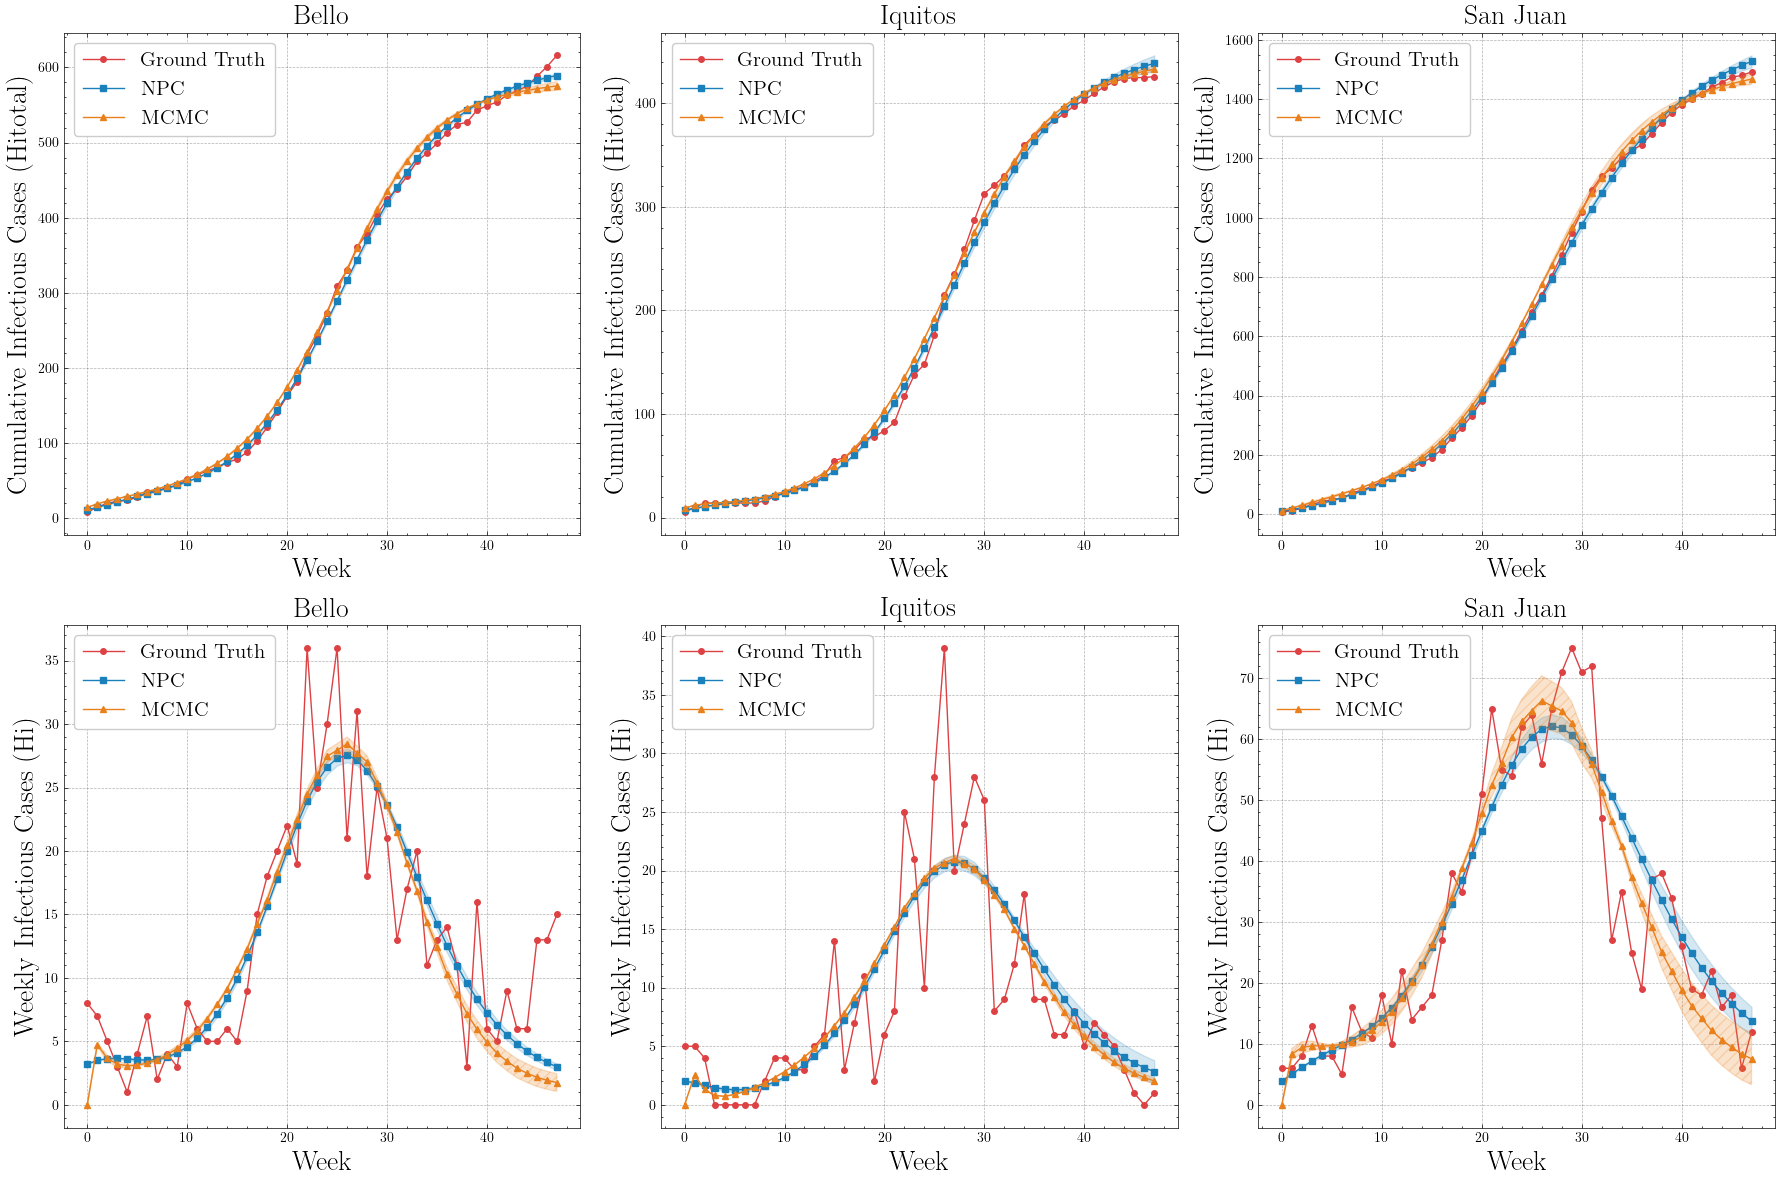

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x3 subplot layout (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
n_rows, n_cols = axes.shape

# Define cities (adjust based on your available data)
cities = ['bello', 'iquitos', 'sanjuan']  # Add 'philippines', 'sanjuan', 'vietnam' as needed

for col, city in enumerate(cities):
    # Hitotal plot (top row)
    ax_Hitotal = axes[0, col]
    ax_Hitotal.plot(eval(f"{city}_Hitotal_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)

    # NPC
    ax_Hitotal.plot(eval(f"{city}_Hitotal_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_Hitotal.fill_between(
        np.arange(len(eval(f"{city}_Hitotal_npc"))), 
        eval(f"{city}_Hitotal_npc") - eval(f"{city}_Hitotal_npc_std"), 
        eval(f"{city}_Hitotal_npc") + eval(f"{city}_Hitotal_npc_std"),
        color='#1a80bb', alpha=0.18, zorder=1
    )

    # MCMC
    ax_Hitotal.plot(eval(f"{city}_Hitotal_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)
    ax_Hitotal.fill_between(
        np.arange(len(eval(f"{city}_Hitotal_mcmc"))), 
        eval(f"{city}_Hitotal_mcmc") - eval(f"{city}_Hitotal_mcmc_std"), 
        eval(f"{city}_Hitotal_mcmc") + eval(f"{city}_Hitotal_mcmc_std"),
        color='#ea801c', alpha=0.22, hatch='///', zorder=2
    )

    if city == "sanjuan":
        ax_Hitotal.set_title(f"San Juan", fontsize=20)
    else:
        ax_Hitotal.set_title(f"{city.title()}", fontsize=20)
    ax_Hitotal.set_xlabel("Week", fontsize=20)
    ax_Hitotal.set_ylabel(" Cumulative Infectious Cases (Hitotal)", fontsize=20)
    ax_Hitotal.legend(loc='upper left', fontsize=15)
    ax_Hitotal.grid(True, alpha=0.3)

    # Hi plot (bottom row) 
    ax_hi = axes[1, col]
    ax_hi.plot(eval(f"{city}_hi_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)

    # NPC
    ax_hi.plot(eval(f"{city}_hi_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_hi.fill_between(
        np.arange(len(eval(f"{city}_hi_npc"))), 
        eval(f"{city}_hi_npc") - eval(f"{city}_hi_npc_std"), 
        eval(f"{city}_hi_npc") + eval(f"{city}_hi_npc_std"),
        color='#1a80bb', alpha=0.18, zorder=1
    )

    # MCMC
    ax_hi.plot(eval(f"{city}_hi_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)
    ax_hi.fill_between(
        np.arange(len(eval(f"{city}_hi_mcmc"))), 
        eval(f"{city}_hi_mcmc") - eval(f"{city}_hi_mcmc_std"), 
        eval(f"{city}_hi_mcmc") + eval(f"{city}_hi_mcmc_std"),
        color='#ea801c', alpha=0.22, hatch='///', zorder=2
    )

    if city == "sanjuan":
        ax_hi.set_title(f"San Juan", fontsize=20)
    else:
        ax_hi.set_title(f"{city.title()}", fontsize=20)
    ax_hi.set_xlabel("Week", fontsize=20)
    ax_hi.set_ylabel("Weekly Infectious Cases (Hi)", fontsize=20)
    ax_hi.legend(loc='upper left', fontsize=15)
    ax_hi.grid(True, alpha=0.3)

plt.tight_layout()
# Save figure with 1200 dpi to TIFF file
fig.savefig("hi_Hitotal_visualization_city.tiff", dpi=300, format='tiff')
plt.show()

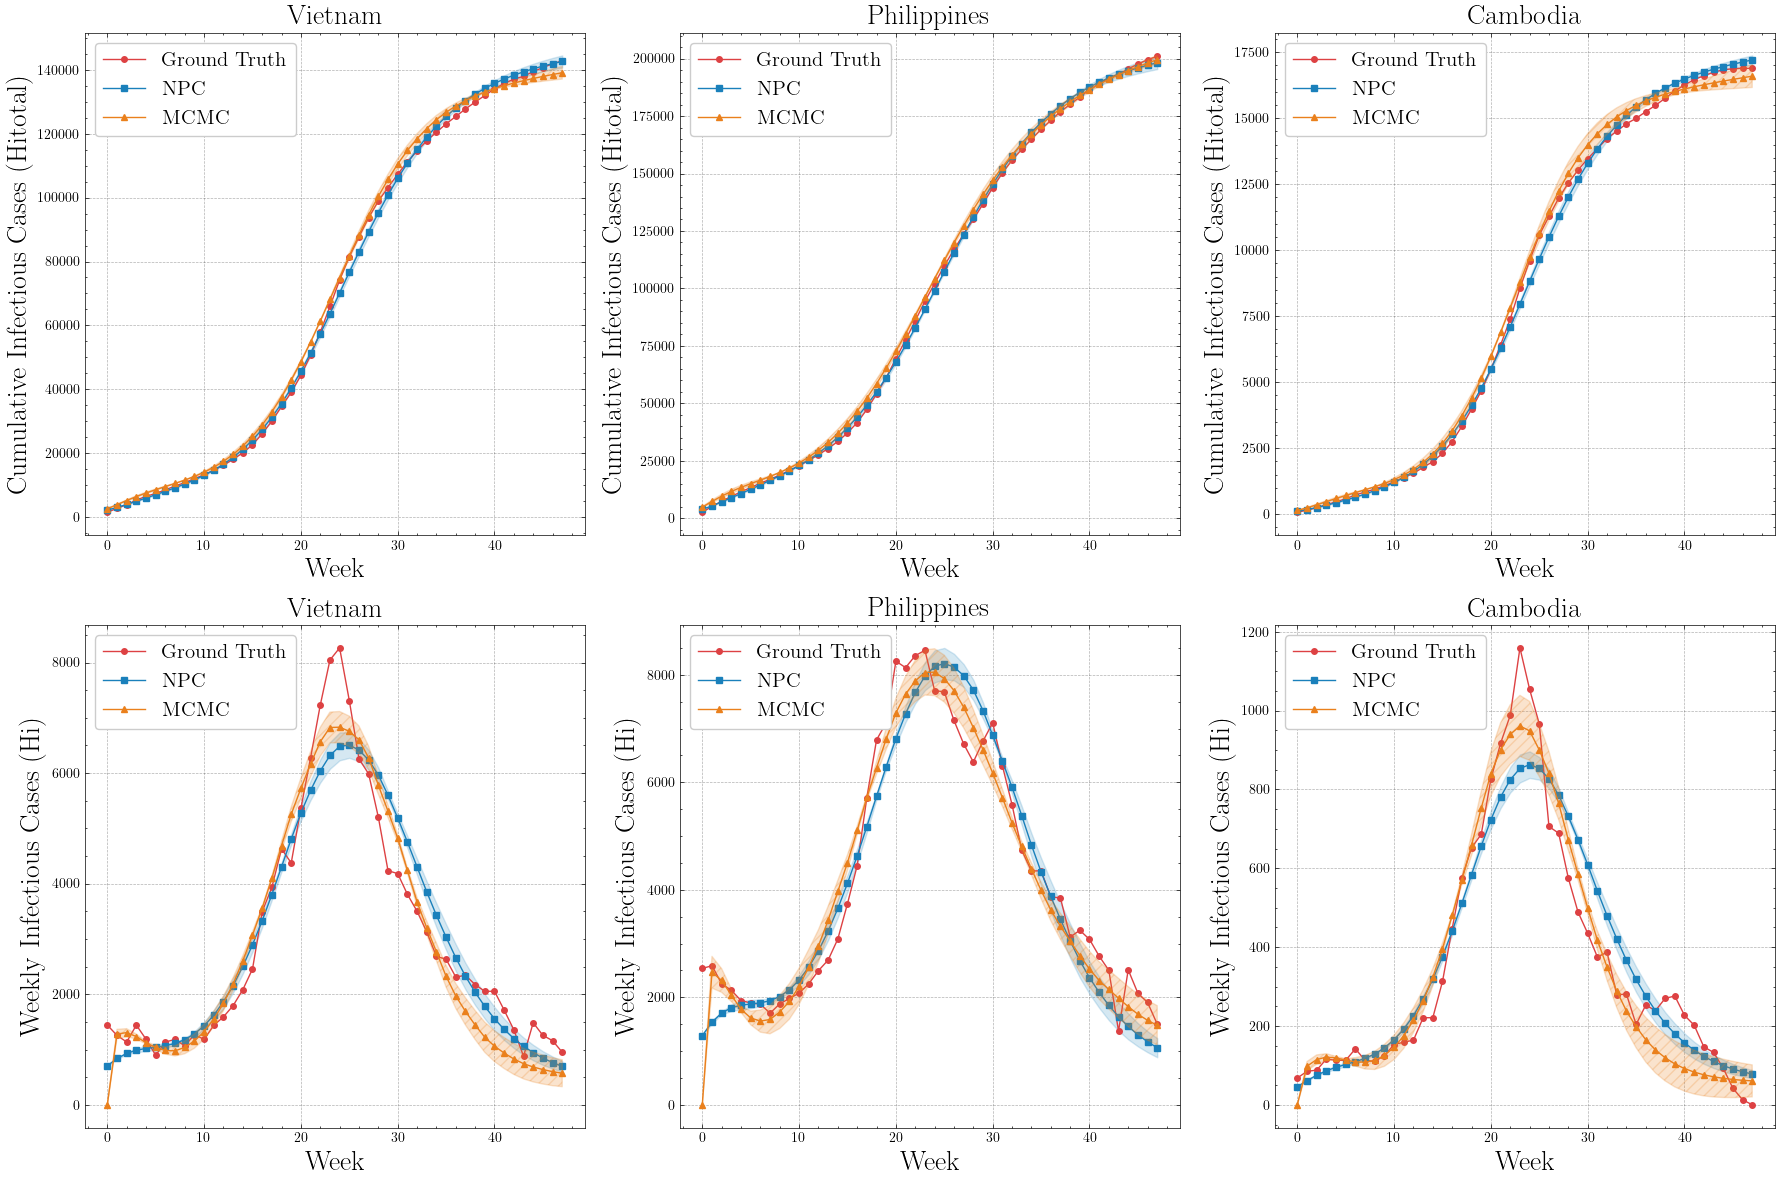

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x3 subplot layout (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
n_rows, n_cols = axes.shape

# Define countries (adjust based on your available data)
countries = ['vietnam', 'philippines', 'cambodia']  # Add 'philippines', 'sanjuan', 'vietnam' as needed

for col, country in enumerate(countries):
    # Hitotal plot (top row)
    ax_Hitotal = axes[0, col]
    ax_Hitotal.plot(eval(f"{country}_Hitotal_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)

    # NPC
    ax_Hitotal.plot(eval(f"{country}_Hitotal_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_Hitotal.fill_between(
        np.arange(len(eval(f"{country}_Hitotal_npc"))), 
        eval(f"{country}_Hitotal_npc") - eval(f"{country}_Hitotal_npc_std"), 
        eval(f"{country}_Hitotal_npc") + eval(f"{country}_Hitotal_npc_std"),
        color='#1a80bb', alpha=0.18, zorder=1
    )

    # MCMC
    ax_Hitotal.plot(eval(f"{country}_Hitotal_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)
    ax_Hitotal.fill_between(
        np.arange(len(eval(f"{country}_Hitotal_mcmc"))), 
        eval(f"{country}_Hitotal_mcmc") - eval(f"{country}_Hitotal_mcmc_std"), 
        eval(f"{country}_Hitotal_mcmc") + eval(f"{country}_Hitotal_mcmc_std"),
        color='#ea801c', alpha=0.22, hatch='///', zorder=2
    )

    ax_Hitotal.set_title(f"{country.title()}", fontsize=20)
    ax_Hitotal.set_xlabel("Week", fontsize=20)
    ax_Hitotal.set_ylabel("Cumulative Infectious Cases (Hitotal)", fontsize=20)
    ax_Hitotal.legend(loc='upper left', fontsize=15)
    ax_Hitotal.grid(True, alpha=0.3)

    # Hi plot (bottom row) 
    ax_hi = axes[1, col]
    ax_hi.plot(eval(f"{country}_hi_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)

    # NPC
    ax_hi.plot(eval(f"{country}_hi_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_hi.fill_between(
        np.arange(len(eval(f"{country}_hi_npc"))), 
        eval(f"{country}_hi_npc") - eval(f"{country}_hi_npc_std"), 
        eval(f"{country}_hi_npc") + eval(f"{country}_hi_npc_std"),
        color='#1a80bb', alpha=0.18, zorder=1
    )

    # MCMC
    ax_hi.plot(eval(f"{country}_hi_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)
    ax_hi.fill_between(
        np.arange(len(eval(f"{country}_hi_mcmc"))), 
        eval(f"{country}_hi_mcmc") - eval(f"{country}_hi_mcmc_std"), 
        eval(f"{country}_hi_mcmc") + eval(f"{country}_hi_mcmc_std"),
        color='#ea801c', alpha=0.22, hatch='///', zorder=2
    )

    ax_hi.set_title(f"{country.title()}", fontsize=20)
    ax_hi.set_xlabel("Week", fontsize=20)
    ax_hi.set_ylabel("Weekly Infectious Cases (Hi)", fontsize=20)
    ax_hi.legend(loc='upper left', fontsize=15)
    ax_hi.grid(True, alpha=0.3)

plt.tight_layout()
# Save figure with 1200 dpi to TIFF file
fig.savefig("hi_Hitotal_visualization_country.tiff", dpi=300, format='tiff')
plt.show()

# Marginal visualisation
A marginal posterior distribution represents the probability distribution of a single parameter obtained by integrating the joint posterior distribution over all other parameters.

Regarding NPC (Neural Parameter Calibration), we train for 2000 epochs, with each epoch producing a set of parameter estimates. The marginal distribution in NPC represents the probability distribution of each parameter obtained from the collection of parameter values generated across all epochs. In MCMC, the marginal distribution of each parameter is obtained through the sampling process, where samples are drawn from the posterior distribution and marginal distributions are derived by considering only the samples of individual parameters while disregarding the values of other parameters.

In [11]:
import h5py
import scipy
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Hi0, Me0, Hr0, Hs0, He0, Ms0, Mi0, beta_h, beta_m, gamma_h, lambda, mu_m, theta_h, theta_m
def plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale, quantile_threshold=0.99):
    """Plot density curves for a parameter with proper normalization"""
    
    # Calculate KDE for each distribution with Scott's rule
    x_range = np.linspace(min_scale, max_scale, 200)
    
    try:
        # Neural Network distribution
        kde_npc = gaussian_kde(data_npc, bw_method=1)
        y_npc = kde_npc(x_range)
        
        # MCMC distribution
        kde_mcmc = gaussian_kde(data_mcmc, bw_method=1)
        y_mcmc = kde_mcmc(x_range)
        
    except np.linalg.LinAlgError:
        # Fallback to histogram-based density estimation
        y_npc, bin_edges = np.histogram(data_npc, bins=50, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        y_mcmc, _ = np.histogram(data_mcmc, bins=bin_edges, density=True)
        x_range = bin_centers
    
    # Plot densities
    ax.plot(x_range, y_npc, color='#1a80bb', lw=2, label='npc')
    ax.fill_between(x_range, y_npc, alpha=0.3, color='#1a80bb')
    ax.plot(x_range, y_mcmc, color='#ea801c', lw=2, label='MCMC')
    ax.fill_between(x_range, y_mcmc, alpha=0.3, color='#ea801c')
    
    # Compute and plot means using direct data
    mean_npc = np.mean(data_npc)
    mean_mcmc = np.mean(data_mcmc)
    
    # Plot mean markers at their actual densities
    ax.scatter(mean_npc, kde_npc(mean_npc),
              color='black', s=30, marker='o', zorder=5)
    ax.scatter(mean_mcmc, kde_mcmc(mean_mcmc),
              color='black', s=30, marker='o', zorder=5)
    
    # Compute and plot modes within parameter range
    mode_idx_npc = np.argmax(y_npc)
    mode_idx_mcmc = np.argmax(y_mcmc)
    mode_npc = x_range[mode_idx_npc]
    mode_mcmc = x_range[mode_idx_mcmc]
    ax.scatter(mode_npc, y_npc[mode_idx_npc], color='grey', s=30, marker='D', zorder=5)
    ax.scatter(mode_mcmc, y_mcmc[mode_idx_mcmc], color='grey', s=30, marker='D', zorder=5)

### Bello, Iquitos and San Juan cities

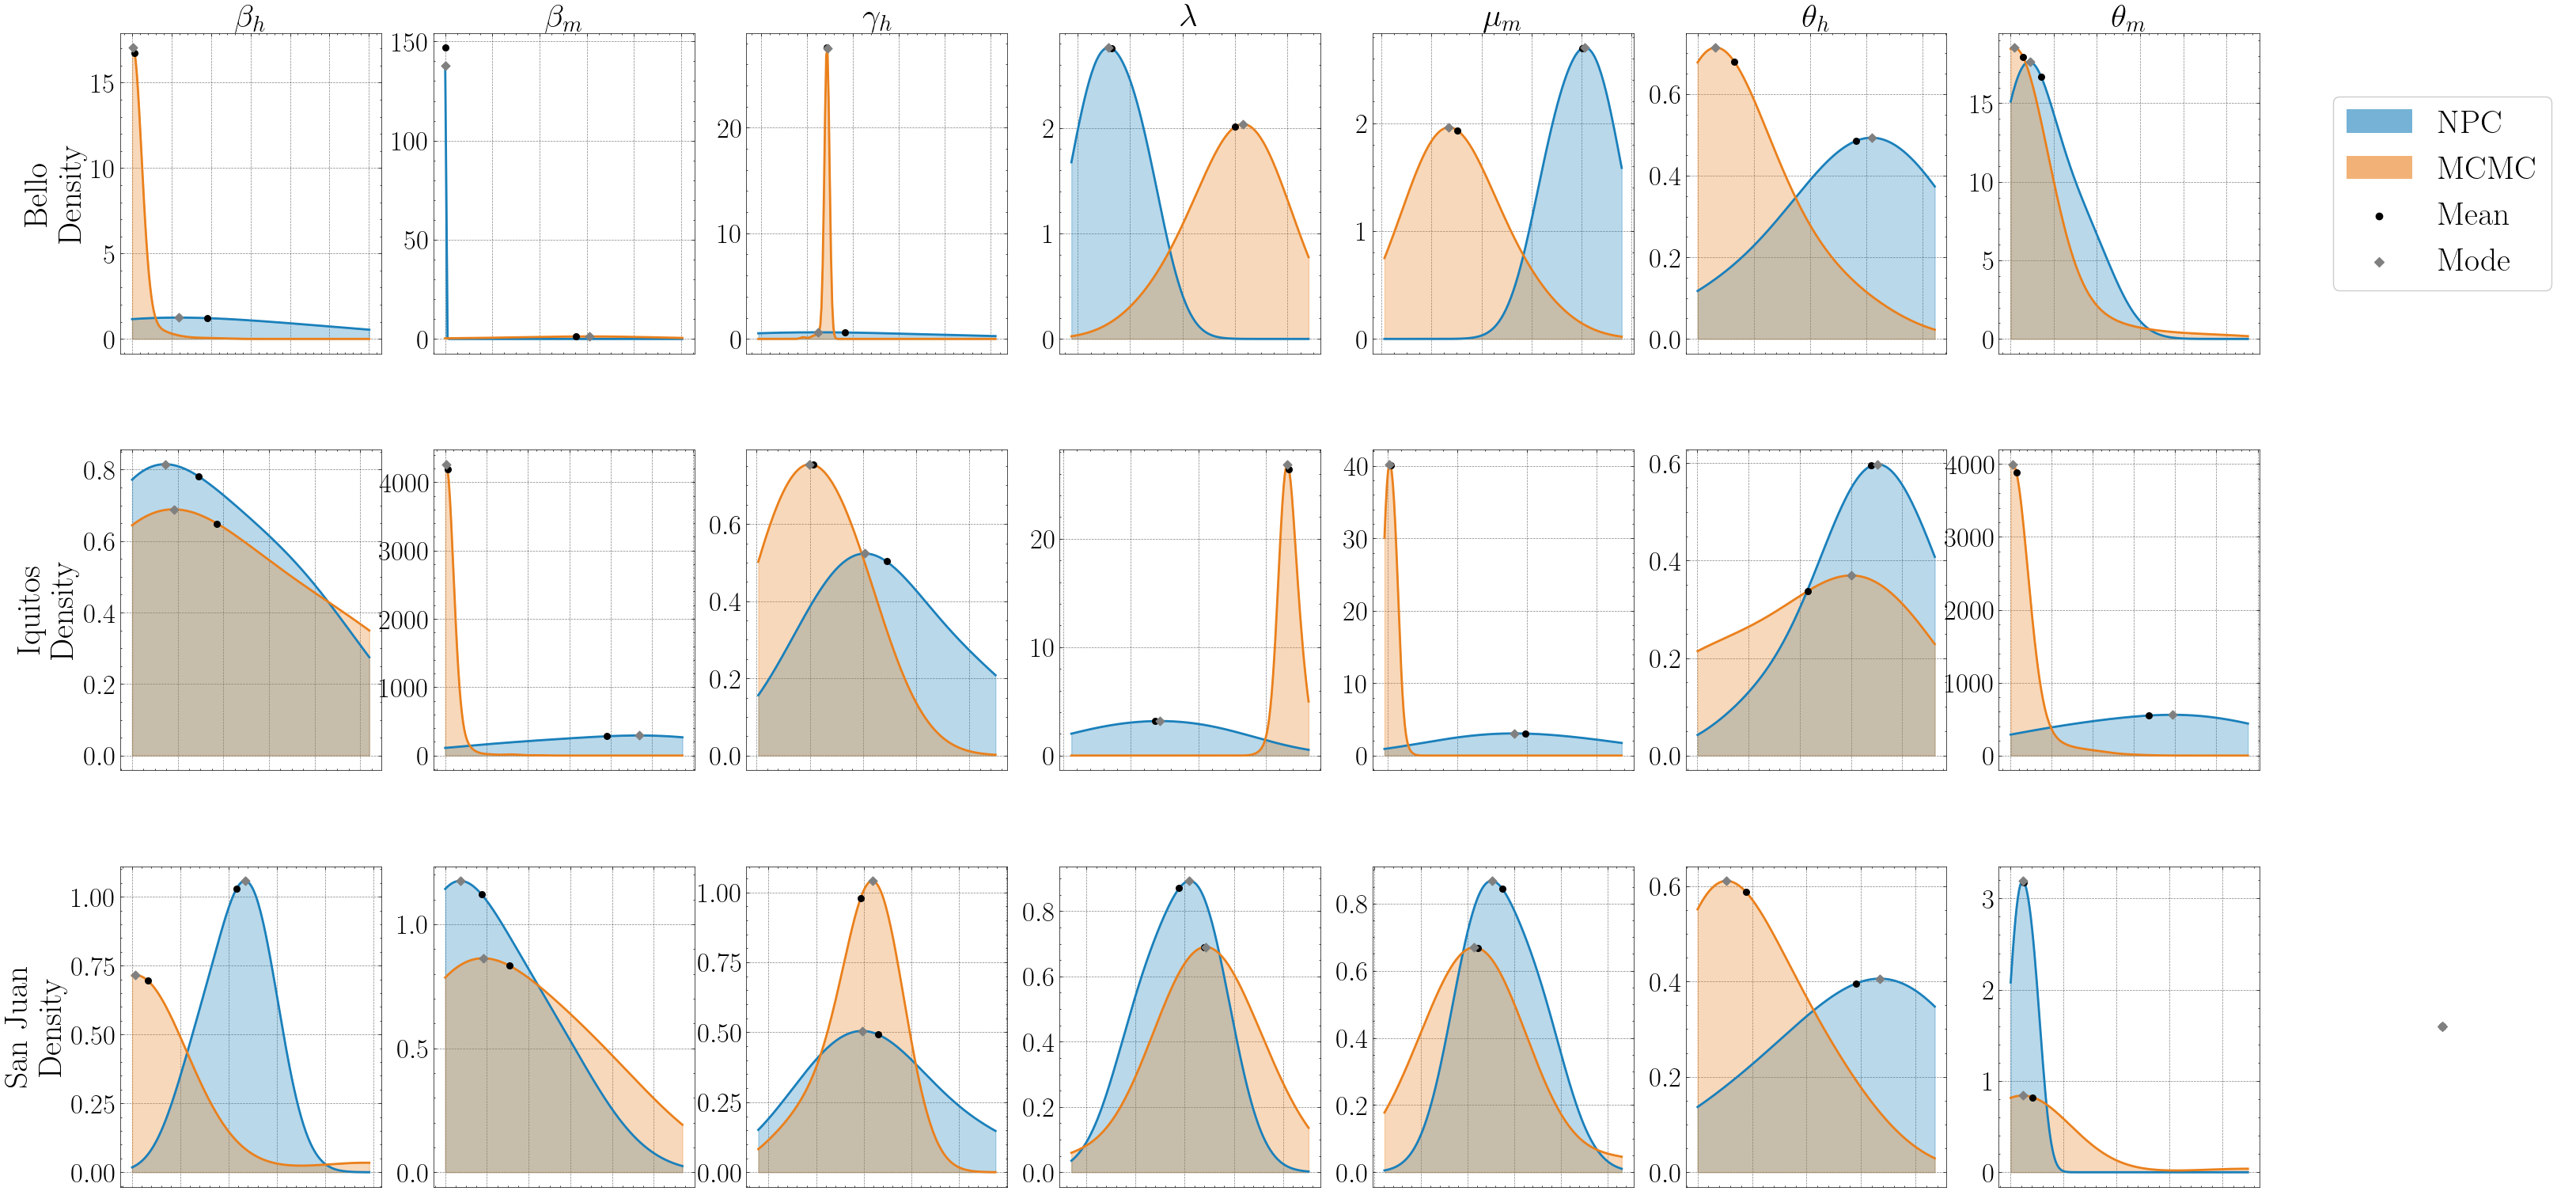

In [12]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda',
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Define cities to plot
cities = ['bello', 'iquitos', 'sanjuan']
city_titles = ['Bello', 'Iquitos', 'San Juan']

# Load data for all cities
all_params_mcmc = []
all_params_npc = []

for city in cities:
    # Load MCMC parameters
    mat = scipy.io.loadmat(f"{city}/{city}_MCMC_all_params.mat")
    params_mcmc = mat[f'{city}_mcmc']
    all_params_mcmc.append(params_mcmc)

    # Load NPC parameters
    param_list = []
    folders = sorted([f for f in os.listdir(f"{city}/data") if f.startswith("uni")])
    for folder in folders:
        h5_path = os.path.join(f"{city}/data", folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        with h5py.File(h5_path, "r") as hf:
            params = hf["Dengue"]["parameters"][-1, :]
            param_list.append(params)
    params_npc = np.vstack(param_list)
    all_params_npc.append(params_npc)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}

# Set up plot grid (3 rows, 8 columns)
nrows, ncols = 3, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(40, 18))

# Add a main title with proper spacing
# fig.suptitle("Marginal Posterior Densities of ODE Parameters", fontsize=40, y=0.98)

# Plot densities for each city and parameter
for city_idx, (city, city_title) in enumerate(zip(cities, city_titles)):
    params_mcmc = all_params_mcmc[city_idx]
    params_npc = all_params_npc[city_idx]

    for param_idx, param in enumerate(param_names):
        ax = axs[city_idx, param_idx]
        data_npc = params_npc[:, param_idx]
        data_mcmc = params_mcmc[param_idx, :]

        # Compute 1th and 99th quantiles from the combined samples for consistent trimming
        q_low_npc, q_high_npc = np.quantile(data_npc.ravel(), [0.01, 0.99])
        q_low_mcmc, q_high_mcmc = np.quantile(data_mcmc.ravel(), [0.01, 0.99])

        # Trim to the central 99% interval
        data_npc = data_npc[(data_npc >= q_low_npc) & (data_npc <= q_high_npc)]
        data_mcmc = data_mcmc[(data_mcmc >= q_low_mcmc) & (data_mcmc <= q_high_mcmc)]

        # If parameter is an initial condition, convert from log-space
        if param in initial_conditions:
            data_npc = data_npc * population
            data_mcmc = data_mcmc * population

        min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
        plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)

        # Set titles only for top row
        if city_idx == 0:
            ax.set_title(math_param_names[param], fontsize=30)

        # Set y-label only for first column
        if param_idx == 0:
            ax.set_ylabel(f"{city_title}\nDensity", fontsize=30)

        # Increase tick label size
        ax.tick_params(axis='y', labelsize=25)
        # ax.tick_params(axis='x', labelsize=25)

        # # Set x-axis limit
        # ax.set_xlim(0, 5)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)  # no marks, no labels


# Add legend only once in the top right corner
legend_ax = axs[0, -1]
legend_ax.axis("off")
handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
          plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
          plt.scatter([0], [0], color='black', marker='o'),
          plt.scatter([0], [0], color='grey', marker='D')]
labels = ['NPC', 'MCMC', 'Mean', 'Mode']
legend_ax.legend(handles, labels, loc='center', fontsize=30)

# Hide the legend positions for other rows
for city_idx in [1, 2]:
    axs[city_idx, -1].axis("off")

# Adjust layout with more spacing
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
plt.savefig('marginal_densities_cities.tiff', dpi=200, format='tiff')
plt.show()

### Vietnam, Cambodia and the Philippines

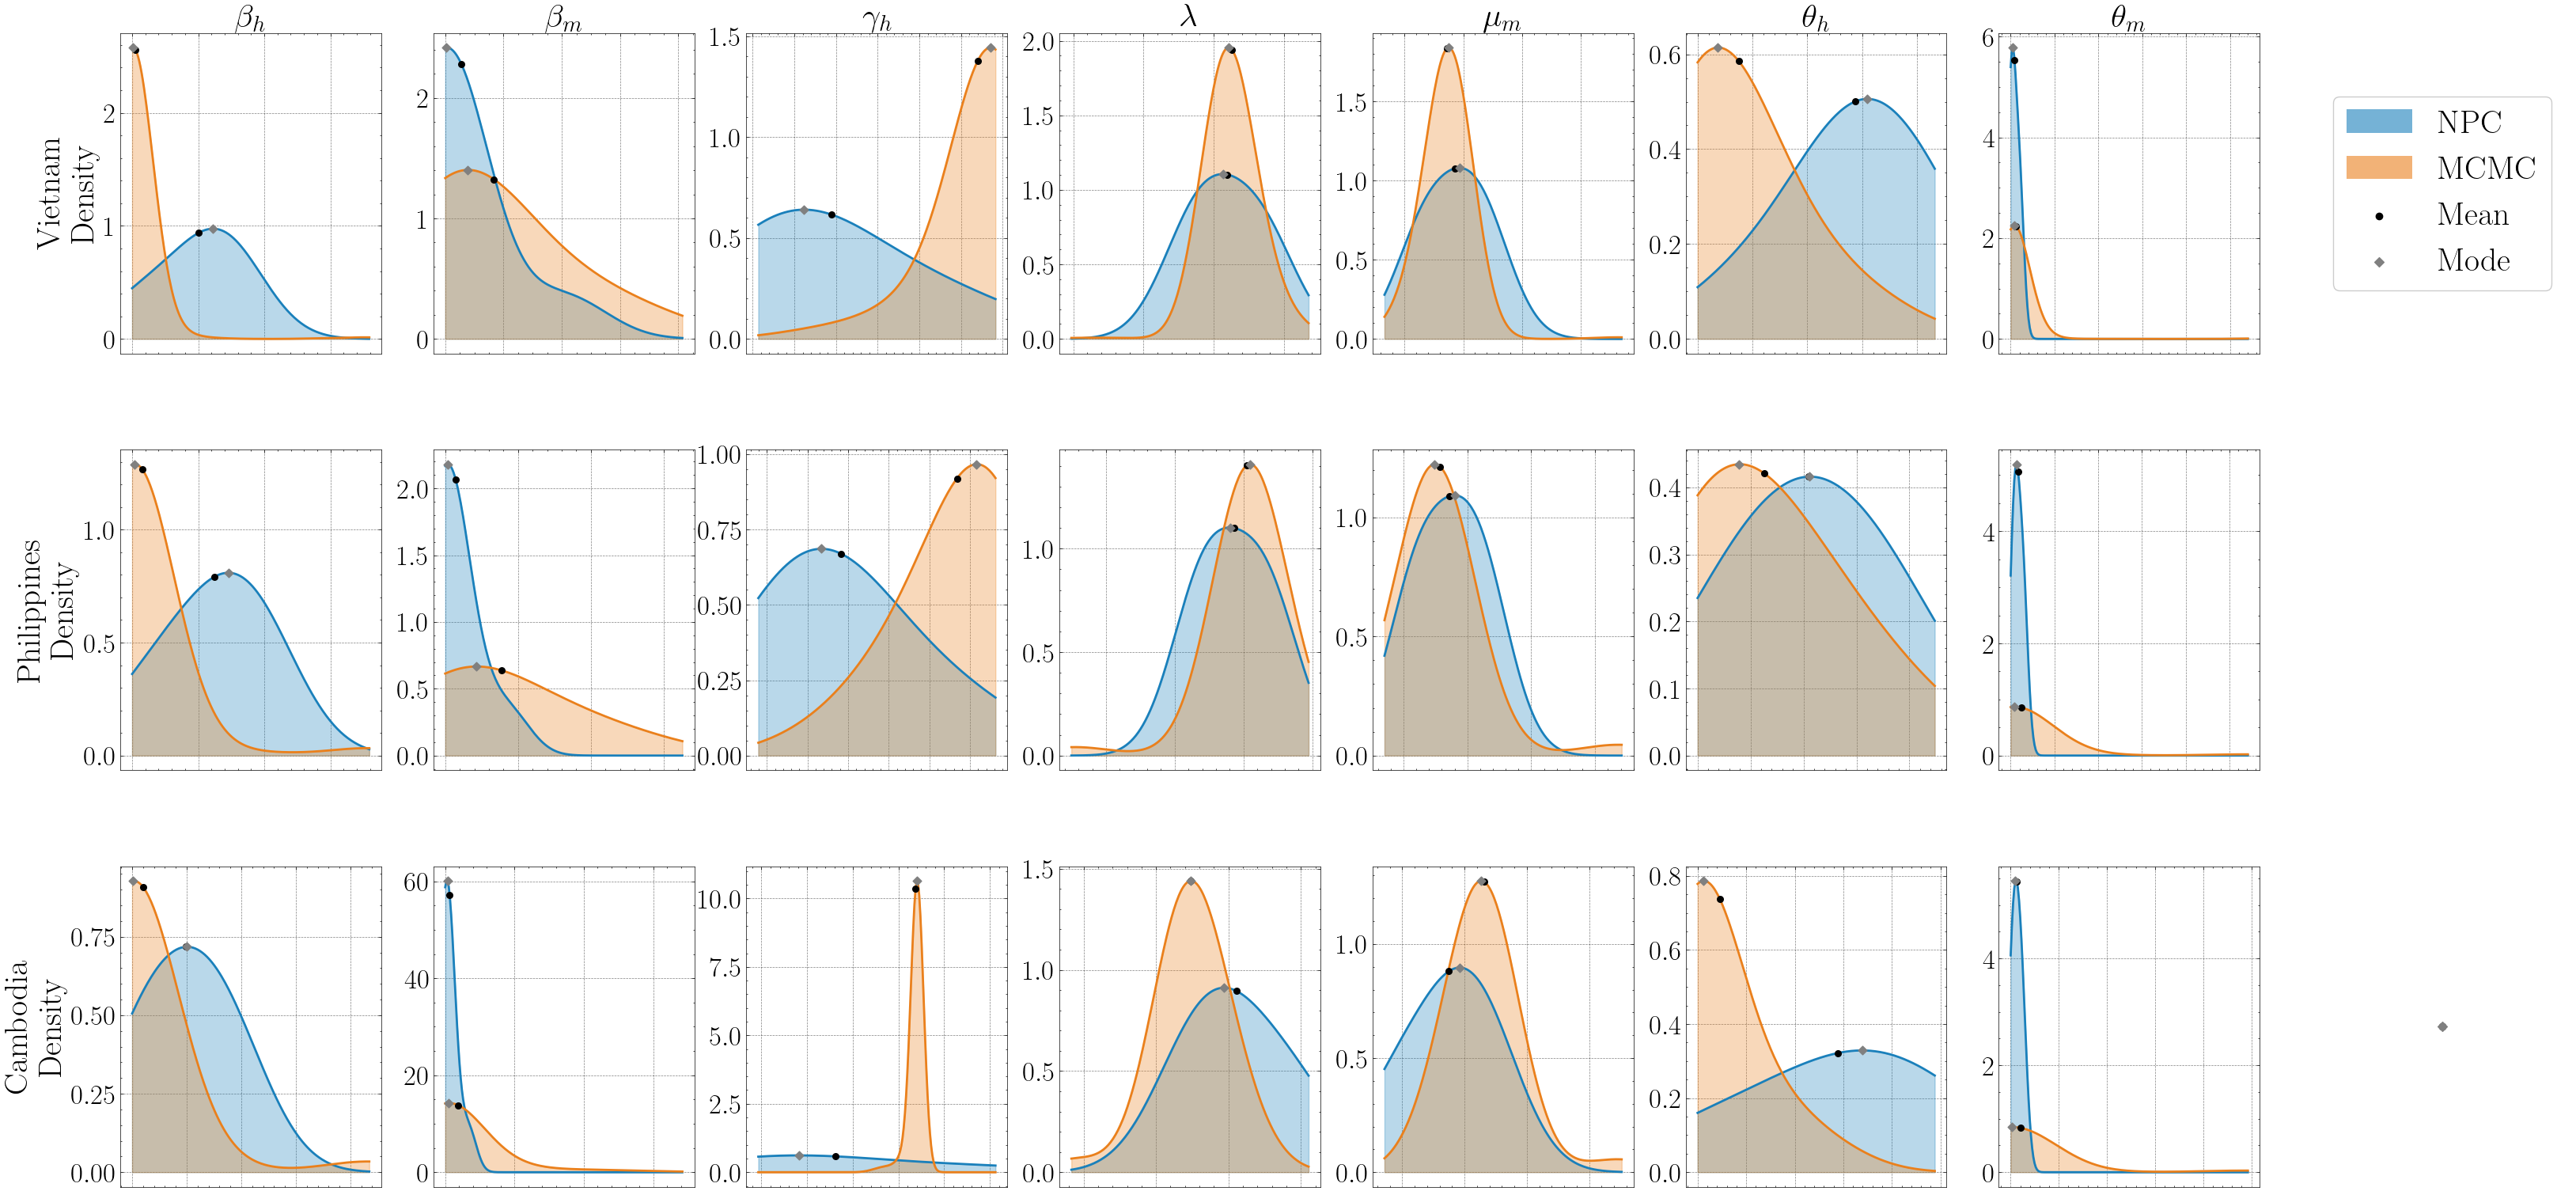

In [13]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda',
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Define countries to plot
countries = ['vietnam', 'philippines', 'cambodia']
country_titles = ['Vietnam', 'Philippines', 'Cambodia']

# Load data for all countries
all_params_mcmc = []
all_params_npc = []

for country in countries:
    # Load MCMC parameters
    mat = scipy.io.loadmat(f"{country}/{country}_MCMC_all_params.mat")
    params_mcmc = mat[f'{country}_mcmc']
    all_params_mcmc.append(params_mcmc)

    # Load NPC parameters
    param_list = []
    folders = sorted([f for f in os.listdir(f"{country}/data") if f.startswith("uni")])
    for folder in folders:
        h5_path = os.path.join(f"{country}/data", folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        with h5py.File(h5_path, "r") as hf:
            params = hf["Dengue"]["parameters"][-1, :]
            param_list.append(params)
    params_npc = np.vstack(param_list)
    all_params_npc.append(params_npc)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}

# Set up plot grid (3 rows, 8 columns)
nrows, ncols = 3, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(40, 18))

# # Add a main title with proper spacing
# fig.suptitle("Marginal Posterior Densities of ODE Parameters", fontsize=40, y=0.98)

# Plot densities for each country and parameter
for country_idx, (country, country_title) in enumerate(zip(countries, country_titles)):
    params_mcmc = all_params_mcmc[country_idx]
    params_npc = all_params_npc[country_idx]

    for param_idx, param in enumerate(param_names):
        ax = axs[country_idx, param_idx]
        data_npc = params_npc[:, param_idx]
        data_mcmc = params_mcmc[param_idx, :]

        # Compute 1st and 99th quantiles from the combined samples for consistent trimming
        q_low_npc, q_high_npc = np.quantile(data_npc.ravel(), [0.01, 0.99])
        q_low_mcmc, q_high_mcmc = np.quantile(data_mcmc.ravel(), [0.01, 0.99])

        # Trim to the central 99% interval
        data_npc = data_npc[(data_npc >= q_low_npc) & (data_npc <= q_high_npc)]
        data_mcmc = data_mcmc[(data_mcmc >= q_low_mcmc) & (data_mcmc <= q_high_mcmc)]

        # If parameter is an initial condition, convert from log-space
        if param in initial_conditions:
            data_npc = data_npc * population
            data_mcmc = data_mcmc * population

        min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
        plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)

        # Set titles only for top row
        if country_idx == 0:
            ax.set_title(math_param_names[param], fontsize=30)

        # Set y-label only for first column
        if param_idx == 0:
            ax.set_ylabel(f"{country_title}\nDensity", fontsize=30)

        # Increase tick label size
        ax.tick_params(axis='y', labelsize=25)
        # ax.tick_params(axis='x', labelsize=25)

        # # Set x-axis limit
        # ax.set_xlim(0, 5)
        ax.tick_params(axis='x', bottom=False, labelbottom=False)  # no marks, no labels

# Add legend only once in the top right corner
legend_ax = axs[0, -1]
legend_ax.axis("off")
handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
          plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
          plt.scatter([0], [0], color='black', marker='o'),
          plt.scatter([0], [0], color='grey', marker='D')]
labels = ['NPC', 'MCMC', 'Mean', 'Mode']
legend_ax.legend(handles, labels, loc='center', fontsize=30)

# Hide the legend positions for other rows
for country_idx in [1, 2]:
    axs[country_idx, -1].axis("off")

# Adjust layout with more spacing
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
plt.savefig('marginal_densities_countries.tiff', dpi=200, format='tiff')
plt.show()

# Compute MSE of NPC and MCMC
This section presents the computation of Hitotal using two approaches: NPC after training, and MCMC following sampling performed in Matlab. Subsequently, we calculate the Mean Squared Error (MSE) loss of Hitotal by comparing the ground truth with NPC and MCMC results, respectively, and visualize these outcomes for comparison.

In [14]:
import os
import glob
import torch
import scipy
import numpy as np
import pandas as pd
import ruamel.yaml as yaml
from os.path import dirname as up
from dantro._import_tools import import_module_from_path

In [15]:
# NEURAL PARAMETERS CALIBRATION
def load_checkpoint(net, filepath):
    """Load model checkpoint from file

    Args:
        net: Model instance to load weights into
        filepath (str): Path to checkpoint file
    """
    try:
        # Load checkpoint
        checkpoint = torch.load(filepath)

        # Restore model state
        net.load_state_dict(checkpoint["model_state_dict"])
        net.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        net.current_loss = checkpoint["loss"]

        # print(f"Model checkpoint loaded from {filepath}")
        return net

    except Exception as e:
        print(f"Error loading checkpoint: {str(e)}")
        raise


def load_model(filepath):
    """Load model from file

    Args:
        filepath (str): Path to model file
    """
    yamlc = yaml.YAML(typ="safe")
    with open(filepath) as cfg_file:
        cfg = yamlc.load(cfg_file)

    current_dir = os.getcwd()
    model_cfg = cfg["parameter_space"]["Dengue"]
    to_learn = model_cfg["Training"]["to_learn"]
    include_path = up(current_dir) + "/include"
    base = import_module_from_path(mod_path=include_path, mod_str="include")

    net = base.NeuralNet(
        # input_size=batch_size,
        input_size=1,  # only Hitotal at t=0
        output_size=len(to_learn),
        **model_cfg["NeuralNet"],
    )
    return net, model_cfg


def apollo_model_7(t, y, params):
    """ODE system for the Dengue model
    Args:
        t: Time point
        y: State vector [Hitotal, Hi, Me, Hr, Hs, He, Ms, Mi]
        parameters: Dictionary containing model parameters
    """
    Hitotal, Hi, Me, Hr, Hs, He, Ms, Mi = y
    lambda_, beta_m, mu_m, theta_m, mu_h, beta_h, theta_h, gamma_h = params

    # Calculate total populations
    H = Hr + Hs + He + Hi  # Total human population
    M = Me + Ms + Mi  # Total mosquito population

    # Ensure populations are not zero
    H = torch.clamp(H, min=1e-8)
    M = torch.clamp(M, min=1e-8)

    # ODE system
    dydt = torch.stack(
        [
            theta_h * He,
            theta_h * He - (gamma_h + mu_h) * Hi,
            beta_m * Hi * Ms / H - (theta_m + mu_m) * Me,
            gamma_h * Hi - mu_h * Hr,
            mu_h * H - beta_h * Mi * Hs / M - mu_h * Hs,
            beta_h * Mi * Hs / M - (theta_h + mu_h) * He,
            lambda_ - beta_m * Hi * Ms / H - mu_m * Ms,
            theta_m * Me - mu_m * Mi,
        ]
    )

    return dydt


def nn_calibrate(nn, Hitotal_true, model_cfg):
    """
    Function to calibrate the model using the neural network predictions.
    """
    # NN predicts parameters & rescale
    Hitotal_true_tensor = torch.tensor(Hitotal_true, dtype=torch.float32).log1p()
    Hitotal0 = torch.tensor(Hitotal_true_tensor[0], dtype=torch.float32).reshape(1, 1)
    pred_params = nn(Hitotal0)
    to_learn = {key: idx for idx, key in enumerate(
        model_cfg["Training"]["to_learn"])}
    all_params = [
        "Hi0", "Me0", "Hr0", "Hs0", "He0", "Ms0", "Mi0", 
        "beta_h", "beta_m", "gamma_h", "lambda", "mu_m", "mu_h", "theta_h", "theta_m",
    ]
    parameters = {
        p: (
            pred_params[to_learn[p]]
            if p in to_learn.keys()
            else torch.tensor(0.0004, dtype=torch.float64)  # mu_h is constant 0.0004
        )
        for p in all_params
    }
    # print("Initial conditions and parameters inferred from NPC:")
    # print({print(param, ": ", val) for param, val in parameters.items()})

    # Perform numerical solver
    Hitotal0 = Hitotal0.squeeze()
    y0 = torch.stack(
        [
            Hitotal0,
            parameters["Hi0"],
            parameters["Me0"],
            parameters["Hr0"],
            parameters["Hs0"],
            parameters["He0"],
            parameters["Ms0"],
            parameters["Mi0"],
        ]
    )
    params = torch.stack(
        [
            parameters["lambda"],
            parameters["beta_m"],
            parameters["mu_m"],
            parameters["theta_m"],
            parameters["mu_h"],
            parameters["beta_h"],
            parameters["theta_h"],
            parameters["gamma_h"],
        ]
    )
    # Setup time points for integration
    t_true = torch.arange(0, 49, dtype=torch.float32)

    # Solve ODE system
    solution = odeint(
        func=lambda y, t: apollo_model_7(y, t, params),
        y0=y0,
        t=t_true,
        method="dopri5",  # dopri5, euler, or rk4
        rtol=1e-3,  # Relaxed tolerance
        atol=1e-6,  # Relaxed absolute tolerance
    )
    # Post-process solution
    npc_Hitotal_pred = torch.abs(solution[1:, 0].squeeze())  # Hitotal variable
    npc_Hitotal_pred = torch.expm1(npc_Hitotal_pred)
    return npc_Hitotal_pred, parameters

In [16]:
# MCMC CALIBRATION
def run_dengue_ode(parameters, Hitotal0, t_true):
    """
    Run the dengue ODE system for a given parameter set and initial Hitotal value.
    Returns the predicted Hitotal time series.
    """
    def apollo_model_7(t, y, params):
        """ODE system for the Dengue model
        Args:
            t: Time point
            y: State vector [Hitotal, Hi, Me, Hr, Hs, He, Ms, Mi]
            parameters: Dictionary containing model parameters
        """
        Hitotal, Hi, Me, Hr, Hs, He, Ms, Mi = y
        lambda_, beta_m, mu_m, theta_m, mu_h, beta_h, theta_h, gamma_h = params

        # Calculate total populations
        H = Hr + Hs + He + Hi  # Total human population
        M = Me + Ms + Mi  # Total mosquito population

        # Ensure populations are not zero
        H = torch.clamp(H, min=1e-8)
        M = torch.clamp(M, min=1e-8)

        # ODE system
        dydt = torch.stack(
            [
                theta_h * He,
                theta_h * He - (gamma_h + mu_h) * Hi,
                beta_m * Hi * Ms / H - (theta_m + mu_m) * Me,
                gamma_h * Hi - mu_h * Hr,
                mu_h * H - beta_h * Mi * Hs / M - mu_h * Hs,
                beta_h * Mi * Hs / M - (theta_h + mu_h) * He,
                lambda_ - beta_m * Hi * Ms / H - mu_m * Ms,
                theta_m * Me - mu_m * Mi,
            ]
        )
        return dydt

    # Initial state
    Hitotal0 = Hitotal0.squeeze(1)
    y0 = torch.stack(
        [
            Hitotal0,
            parameters["Hi0"],
            parameters["Me0"],
            parameters["Hr0"],
            parameters["Hs0"],
            parameters["He0"],
            parameters["Ms0"],
            parameters["Mi0"],
        ]
    )
    params = torch.stack(
        [
            parameters["lambda"],
            parameters["beta_m"],
            parameters["mu_m"],
            parameters["theta_m"],
            parameters["mu_h"],
            parameters["beta_h"],
            parameters["theta_h"],
            parameters["gamma_h"],
        ]
    )
    
    # Solve ODE system
    solution = odeint(
        func=lambda y, t: apollo_model_7(y, t, params),
        y0=y0,
        t=t_true,
        method="dopri5",  # dopri5, euler, or rk4
        rtol=1e-3,  # Relaxed tolerance
        atol=1e-6,  # Relaxed absolute tolerance
    )
    
    # Post-process solution
    mcmc_Hitotal_pred = torch.abs(solution[1:, 0].squeeze())  # Hitotal variable
    mcmc_Hitotal_pred = torch.expm1(mcmc_Hitotal_pred)
    return mcmc_Hitotal_pred

def mcmc_estimate(mat_path, mat_name, Hitotal_true, t_points, param_names=None):
    """
    Load MCMC parameters from .mat file, run ODE for each, compute loss to ground truth,
    and select the prediction with the smallest loss but closest to NPC prediction.
    Returns: best_pred_Hitotal, best_loss, best_params
    """
    if param_names is None:
        param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0',
                       'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']
    mat = scipy.io.loadmat(mat_path)
    params_mcmc = mat[mat_name]  # shape: (n_parameters, 1)
    Hitotal_true_tensor = torch.tensor(Hitotal_true, dtype=torch.float64).log1p()
    mse_loss = torch.nn.MSELoss()
    best_params = None

    p = params_mcmc[:]
    params = {name: torch.tensor(p[j]) for j, name in enumerate(param_names)}
    params["mu_h"] = torch.tensor([0.0004], dtype=torch.float64)  # constant
    best_params = params
    Hitotal0 = torch.tensor(Hitotal_true_tensor[0], dtype=torch.float64).reshape(1, 1)

    # Run ODE with current parameters
    mcmc_Hitotal = run_dengue_ode(params, Hitotal0, t_points)
    mcmc_Hitotal_tensor = torch.tensor(mcmc_Hitotal, dtype=torch.float64).log1p()
    mcmc_loss = mse_loss(mcmc_Hitotal_tensor, Hitotal_true_tensor).item()
    
    return mcmc_Hitotal, mcmc_loss, best_params

## Compute MSE for Calibration dataset

### Bello

In [17]:
cfg_file_path = "../models/Dengue/cfgs/bello/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/bello/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./bello/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on calibration set
    mse_Hitotal_npc_cali = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_cali.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "bello/bello_MCMC_best_params.mat", "bello_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hitotal_mcmc_bello_cali = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_bello_cali = total_npc_mse / count
    print(f"Average MSE NPC on calibration set (across {count} uni folders): {mse_Hitotal_npc_bello_cali}")
    print(f"MSE MCMC on calibration set: {mse_Hitotal_mcmc_bello_cali}")
else:
    print("No valid uni folders found.")

Average MSE NPC on calibration set (across 10 uni folders): 0.003562669362872839
MSE MCMC on calibration set: 0.012664057314395905


In [18]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params_mcmc.items():
    print(f'{key}: {value[0]}')

Hi0: 1.6131847757435e-06
Me0: 0.4818522197859998
Hr0: 1.1104813686390353
Hs0: 3.288216027318831
He0: 0.8046307992341207
Ms0: 6.472763182153173e-06
Mi0: 3.838992380543742e-14
beta_h: 0.9343688657670515
beta_m: 0.06088400253249314
gamma_h: 1.3787041838715056e-05
lambda: 1.8423248677675206
mu_m: 0.03335749531713348
theta_h: 1.0260442185320107
theta_m: 0.2064074997932324
mu_h: 0.0004


### Iquitos

In [19]:
cfg_file_path = "../models/Dengue/cfgs/iquitos/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/iquitos/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./iquitos/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on calibration set
    mse_Hitotal_npc_cali = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_cali.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "iquitos/iquitos_MCMC_best_params.mat", "iquitos_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hitotal_mcmc_iquitos_cali = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_iquitos_cali = total_npc_mse / count
    print(f"Average MSE NPC on calibration set (across {count} uni folders): {mse_Hitotal_npc_iquitos_cali}")
    print(f"MSE MCMC on calibration set: {mse_Hitotal_mcmc_iquitos_cali}")
else:
    print("No valid uni folders found.")

Average MSE NPC on calibration set (across 10 uni folders): 0.009529093652963639
MSE MCMC on calibration set: 0.014426224865019321


In [20]:
# Initial conditions and parameters inferred from MCMC
print("Initial conditions and parameters inferred from MCMC:")
for key, value in best_params_mcmc.items():
    print(f'{key}: {value[0]}')

Initial conditions and parameters inferred from MCMC:
Hi0: 0.06636595397133503
Me0: 2.7299917007677188e-14
Hr0: 0.03104366940734174
Hs0: 3.3419205922518254
He0: 0.9066370612103022
Ms0: 1.6206706854992385
Mi0: 1.000000028552119e-06
beta_h: 1.4238252491888665
beta_m: 0.10446776371708079
gamma_h: 0.27976496745080603
lambda: 0.20824799908101213
mu_m: 1.4924622307766453e-06
theta_h: 0.8928339999999777
theta_m: 0.15681693496318977
mu_h: 0.0004


### San Juan

In [21]:
cfg_file_path = "../models/Dengue/cfgs/sanjuan/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/sanjuan/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./sanjuan/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on calibration set
    mse_Hitotal_npc_cali = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_cali.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "sanjuan/sanjuan_MCMC_best_params.mat", "sanjuan_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hitotal_mcmc_sanjuan_cali = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_sanjuan_cali = total_npc_mse / count
    print(f"Average MSE NPC on calibration set (across {count} uni folders): {mse_Hitotal_npc_sanjuan_cali}")
    print(f"MSE MCMC on calibration set: {mse_Hitotal_mcmc_sanjuan_cali}")
else:
    print("No valid uni folders found.")

Average MSE NPC on calibration set (across 10 uni folders): 0.007248221151530743
MSE MCMC on calibration set: 0.02206648886203766


In [22]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params_mcmc.items():
    print(f'{key}: {value[0]}')

Hi0: 0.00016342449867498036
Me0: 0.8279705210723719
Hr0: 1.6484607412365395
Hs0: 4.557693662334342
He0: 0.7037101590887095
Ms0: 0.4061104922786206
Mi0: 0.33099073023926906
beta_h: 0.8904898451821236
beta_m: 0.10736815509623458
gamma_h: 0.0015427403929115032
lambda: 1.8317099987665235
mu_m: 0.05142292127556542
theta_h: 0.862492011925729
theta_m: 0.07806869717274466
mu_h: 0.0004


### Vienam

In [23]:
cfg_file_path = "../models/Dengue/cfgs/vietnam/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/vietnam/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./vietnam/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on calibration set
    mse_Hitotal_npc_cali = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_cali.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "vietnam/vietnam_MCMC_best_params.mat", "vietnam_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hitotal_mcmc_vietnam_cali = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_vietnam_cali = total_npc_mse / count
    print(f"Average MSE NPC on calibration set (across {count} uni folders): {mse_Hitotal_npc_vietnam_cali}")
    print(f"MSE MCMC on calibration set: {mse_Hitotal_mcmc_vietnam_cali}")
else:
    print("No valid uni folders found.")

Average MSE NPC on calibration set (across 10 uni folders): 0.004949971497990191
MSE MCMC on calibration set: 0.015616361983120441


In [24]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params_mcmc.items():
    print(f'{key}: {value[0]}')

Hi0: 1.7859135470426593
Me0: 0.5670808678366992
Hr0: 2.2068279993284174
Hs0: 2.5558622651317138
He0: 1.8906668309351802
Ms0: 0.022752547048931187
Mi0: 1.0000000400279797e-06
beta_h: 1.0329015372069843
beta_m: 0.2050992105072137
gamma_h: 7.328193028142224e-07
lambda: 2.25108661017595
mu_m: 0.013479680994806663
theta_h: 0.35787602711676453
theta_m: 0.0458449465548255
mu_h: 0.0004


### Philippines

In [25]:
cfg_file_path = "../models/Dengue/cfgs/philippines/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/philippines/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./philippines/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on calibration set
    mse_Hitotal_npc_cali = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_cali.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "philippines/philippines_MCMC_best_params.mat", "philippines_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hitotal_mcmc_philippines_cali = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_philippines_cali = total_npc_mse / count
    print(f"Average MSE NPC on calibration set (across {count} uni folders): {mse_Hitotal_npc_philippines_cali}")
    print(f"MSE MCMC on calibration set: {mse_Hitotal_mcmc_philippines_cali}")
else:
    print("No valid uni folders found.")

Average MSE NPC on calibration set (across 10 uni folders): 0.004494136059656739
MSE MCMC on calibration set: 0.016259407624602318


In [26]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params_mcmc.items():
    print(f'{key}: {value[0]}')

Hi0: 2.2657396377636507e-05
Me0: 0.003292195981165599
Hr0: 1.8125986181842229
Hs0: 2.90761375555966
He0: 1.6202314913429132
Ms0: 2.239589616292214
Mi0: 0.07692536902002563
beta_h: 0.6134114938333739
beta_m: 0.22603602310780013
gamma_h: 0.04947039722330503
lambda: 0.006633354560178032
mu_m: 0.17381195756459467
theta_h: 0.4889545053366613
theta_m: 0.032853047944700245
mu_h: 0.0004


### Cambodia

In [27]:
cfg_file_path = "../models/Dengue/cfgs/cambodia/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/cambodia/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./cambodia/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on calibration set
    mse_Hitotal_npc_cali = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_cali.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "cambodia/cambodia_MCMC_best_params.mat", "cambodia_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hitotal_mcmc_cambodia_cali = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_cambodia_cali = total_npc_mse / count
    print(f"Average MSE NPC on calibration set (across {count} uni folders): {mse_Hitotal_npc_cambodia_cali}")
    print(f"MSE MCMC on calibration set: {mse_Hitotal_mcmc_cambodia_cali}")
else:
    print("No valid uni folders found.")

Average MSE NPC on calibration set (across 10 uni folders): 0.008706993283703923
MSE MCMC on calibration set: 0.025059426203370094


In [28]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params_mcmc.items():
    print(f'{key}: {value[0]}')

Hi0: 0.9248869458878589
Me0: 1.0011141309591103e-05
Hr0: 1.8533059061279227
Hs0: 2.612859817178273
He0: 2.7537568369346217
Ms0: 0.020393755933268466
Mi0: 0.0003130403545716028
beta_h: 1.4941253503956966
beta_m: 0.12688519392622166
gamma_h: 5.663440361238564e-07
lambda: 1.8676539644125576
mu_m: 0.00012657163454958233
theta_h: 0.2990626450577667
theta_m: 0.06804145742487523
mu_h: 0.0004


## Compute MSE for Projection set

### Bello

In [29]:
cfg_file_path = "../models/Dengue/cfgs/bello/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/bello/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./bello/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on projection set
    mse_Hitotal_npc_proj = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_proj.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "bello/bello_MCMC_best_params.mat", "bello_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hitotal_mcmc_bello_proj = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_bello_proj = total_npc_mse / count
    print(f"Average MSE NPC on projection set (across {count} uni folders): {mse_Hitotal_npc_bello_proj}")
    print(f"MSE MCMC on projection set: {mse_Hitotal_mcmc_bello_proj}")
else:
    print("No valid uni folders found.")

Average MSE NPC on projection set (across 10 uni folders): 0.0823631875216961
MSE MCMC on projection set: 0.06822405010461807


### Iquitos

In [30]:
cfg_file_path = "../models/Dengue/cfgs/iquitos/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/iquitos/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./iquitos/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on projection set
    mse_Hitotal_npc_proj = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_proj.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "iquitos/iquitos_MCMC_best_params.mat", "iquitos_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hitotal_mcmc_iquitos_proj = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_iquitos_proj = total_npc_mse / count
    print(f"Average MSE NPC on projection set (across {count} uni folders): {mse_Hitotal_npc_iquitos_proj}")
    print(f"MSE MCMC on projection set: {mse_Hitotal_mcmc_iquitos_proj}")
else:
    print("No valid uni folders found.")

Average MSE NPC on projection set (across 10 uni folders): 0.49629956781864165
MSE MCMC on projection set: 0.423149973154068


### San Juan

In [31]:
cfg_file_path = "../models/Dengue/cfgs/sanjuan/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/sanjuan/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./sanjuan/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on projection set
    mse_Hitotal_npc_proj = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_proj.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "sanjuan/sanjuan_MCMC_best_params.mat", "sanjuan_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hitotal_mcmc_sanjuan_proj = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_sanjuan_proj = total_npc_mse / count
    print(f"Average MSE NPC on projection set (across {count} uni folders): {mse_Hitotal_npc_sanjuan_proj}")
    print(f"MSE MCMC on projection set: {mse_Hitotal_mcmc_sanjuan_proj}")
else:
    print("No valid uni folders found.")

Average MSE NPC on projection set (across 10 uni folders): 0.865317440032959
MSE MCMC on projection set: 0.9444250464439392


### Vietnam

In [32]:
cfg_file_path = "../models/Dengue/cfgs/vietnam/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/vietnam/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./vietnam/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on projection set
    mse_Hitotal_npc_proj = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_proj.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "vietnam/vietnam_MCMC_best_params.mat", "vietnam_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hitotal_mcmc_vietnam_proj = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_vietnam_proj = total_npc_mse / count
    print(f"Average MSE NPC on projection set (across {count} uni folders): {mse_Hitotal_npc_vietnam_proj}")
    print(f"MSE MCMC on projection set: {mse_Hitotal_mcmc_vietnam_proj}")
else:
    print("No valid uni folders found.")

Average MSE NPC on projection set (across 10 uni folders): 0.3362783551216125
MSE MCMC on projection set: 0.2967239320278168


### Philippines

In [33]:
cfg_file_path = "../models/Dengue/cfgs/philippines/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/philippines/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./philippines/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on projection set
    mse_Hitotal_npc_proj = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_proj.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "philippines/philippines_MCMC_best_params.mat", "philippines_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hitotal_mcmc_philippines_proj = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_philippines_proj = total_npc_mse / count
    print(f"Average MSE NPC on projection set (across {count} uni folders): {mse_Hitotal_npc_philippines_proj}")
    print(f"MSE MCMC on projection set: {mse_Hitotal_mcmc_philippines_proj}")
else:
    print("No valid uni folders found.")

Average MSE NPC on projection set (across 10 uni folders): 0.24338236451148987
MSE MCMC on projection set: 0.21467411518096924


### Cambodia

In [34]:
cfg_file_path = "../models/Dengue/cfgs/cambodia/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
Hitotal_true = torch.tensor(pd.read_csv(
    "../data/Dengue/cambodia/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
Hitotal_true_tensor = Hitotal_true.log1p()  # Log scaling

# Initialize accumulators for averaging
total_npc_mse = 0.0
total_mcmc_mse = 0.0
count = 0

# Loop through each uni folder
uni_folders = sorted(glob.glob("./cambodia/data/uni*/"))

for uni_path in uni_folders:
    uni_name = os.path.basename(uni_path.rstrip('/'))

    # Load model
    checkpoint_path = f"{uni_path}data_npc_checkpoint.pth"
    if not os.path.exists(checkpoint_path):
        continue
    nn = load_checkpoint(net, checkpoint_path)

    # NPC variables estimation
    Hitotal_npc, npc_parameters = nn_calibrate(nn, Hitotal_true, model_cfg)
    Hitotal_npc_tensor = Hitotal_npc.log1p()

    # Compute loss of NPC on projection set
    mse_Hitotal_npc_proj = mse_loss(
        Hitotal_npc_tensor, Hitotal_true_tensor
    )

    # Accumulate losses
    total_npc_mse += mse_Hitotal_npc_proj.item()
    count += 1

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
Hitotal_mcmc, _, best_params_mcmc = mcmc_estimate(
    "cambodia/cambodia_MCMC_best_params.mat", "cambodia_mcmc", Hitotal_true, t_points)
Hitotal_mcmc_tensor = torch.tensor(Hitotal_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hitotal_mcmc_cambodia_proj = mse_loss(
    Hitotal_mcmc_tensor, Hitotal_true_tensor
)

# Compute and print average MSE across all uni folders
if count > 0:
    mse_Hitotal_npc_cambodia_proj = total_npc_mse / count
    print(f"Average MSE NPC on projection set (across {count} uni folders): {mse_Hitotal_npc_cambodia_proj}")
    print(f"MSE MCMC on projection set: {mse_Hitotal_mcmc_cambodia_proj}")
else:
    print("No valid uni folders found.")

Average MSE NPC on projection set (across 10 uni folders): 0.10160445794463158
MSE MCMC on projection set: 0.10018055886030197


## Visualize Calibration and Projection MSE

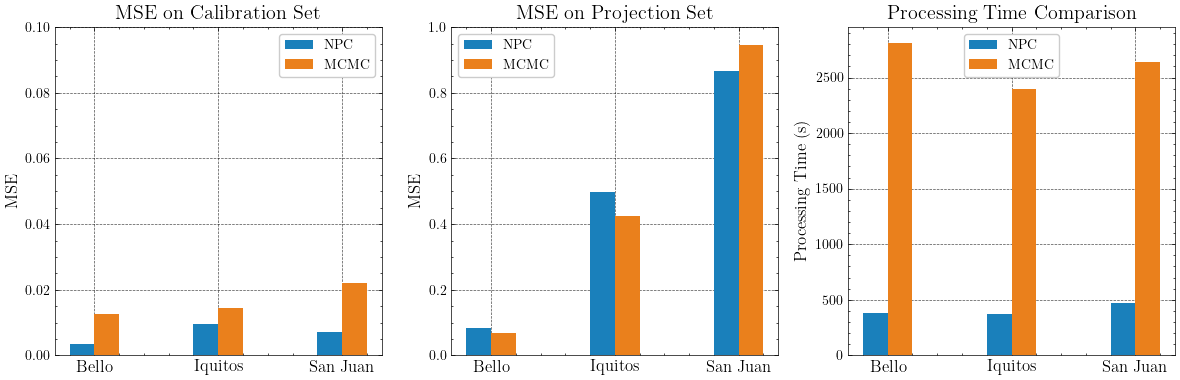

In [35]:
# Visualize the time and error
mse_cali = {
    "Bello":    [mse_Hitotal_npc_bello_cali, mse_Hitotal_mcmc_bello_cali], 
    "Iquitos":  [mse_Hitotal_npc_iquitos_cali, mse_Hitotal_mcmc_iquitos_cali], 
    "San Juan":  [mse_Hitotal_npc_sanjuan_cali, mse_Hitotal_mcmc_sanjuan_cali],
}
mse_proj = {
    "Bello":    [mse_Hitotal_npc_bello_proj, mse_Hitotal_mcmc_bello_proj], 
    "Iquitos":  [mse_Hitotal_npc_iquitos_proj, mse_Hitotal_mcmc_iquitos_proj], 
    "San Juan":  [mse_Hitotal_npc_sanjuan_proj, mse_Hitotal_mcmc_sanjuan_proj],
}
process_time = {"Bello": [383, 2812.6453], "Iquitos": [371, 2397.2065], "San Juan": [470, 2638.1834]}

# Cities and labels
cities = list(mse_cali.keys())
labels = ["NPC", "MCMC"]

# Generate bar plot for MSE
x = np.arange(len(cities))
width = 0.2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# MSE on Calibration set
ax[0].bar(
    x - width / 2,
    [mse_cali[city][0] for city in cities],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[0].bar(
    x + width / 2,
    [mse_cali[city][1] for city in cities],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[0].set_title("MSE on Calibration Set", fontsize="x-large")
ax[0].set_ylabel("MSE", fontsize="large")
ax[0].set_xticks(x)
ax[0].set_xticklabels(cities, fontsize="large")
ax[0].legend(fontsize="medium")
ax[0].grid(True, linestyle="--", alpha=0.7)

# MSE on Projection set
ax[1].bar(
    x - width / 2,
    [mse_proj[city][0] for city in cities],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[1].bar(
    x + width / 2,
    [mse_proj[city][1] for city in cities],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[1].set_title("MSE on Projection Set", fontsize="x-large")
ax[1].set_ylabel("MSE", fontsize="large")
ax[1].set_xticks(x)
ax[1].set_xticklabels(cities, fontsize="large")
ax[1].legend(fontsize="medium")
ax[1].grid(True, linestyle="--", alpha=0.7)

# Processing time plot
ax[2].bar(
    x - width / 2,
    [process_time[city][0] for city in cities],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[2].bar(
    x + width / 2,
    [process_time[city][1] for city in cities],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[2].set_title("Processing Time Comparison", fontsize="x-large")
ax[2].set_ylabel("Processing Time (s)", fontsize="large")
ax[2].set_xticks(x)
ax[2].set_xticklabels(cities, fontsize="large")
ax[2].legend(fontsize="medium")
ax[2].grid(True, linestyle="--", alpha=0.7)

# Set y-axis range to (0, 1)
ax[0].set_ylim(0, 0.1)
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("mse_calibration_projection_processing_time_city.tiff", dpi=700, format='tiff')
plt.show()

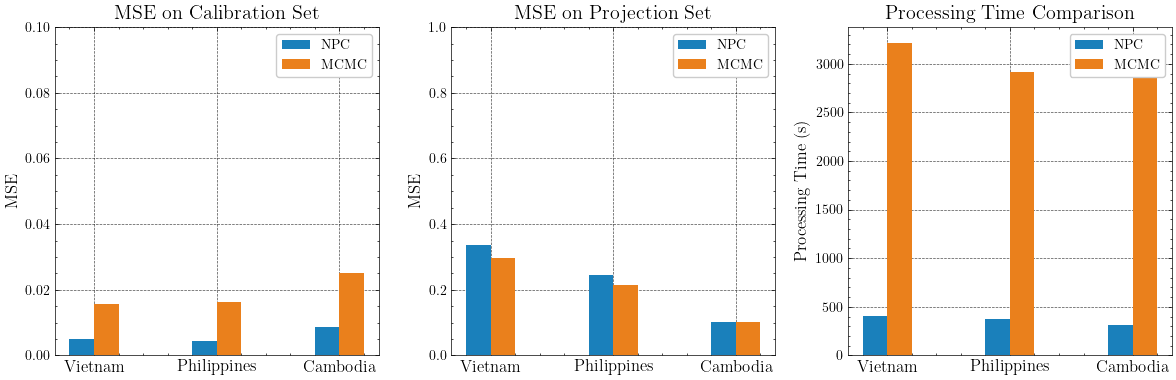

In [36]:
# Visualize the time and error
mse_cali = {
    "Vietnam":    [mse_Hitotal_npc_vietnam_cali, mse_Hitotal_mcmc_vietnam_cali], 
    "Philippines":  [mse_Hitotal_npc_philippines_cali, mse_Hitotal_mcmc_philippines_cali], 
    "Cambodia":  [mse_Hitotal_npc_cambodia_cali, mse_Hitotal_mcmc_cambodia_cali],
}
mse_proj = {
    "Vietnam":    [mse_Hitotal_npc_vietnam_proj, mse_Hitotal_mcmc_vietnam_proj], 
    "Philippines":  [mse_Hitotal_npc_philippines_proj, mse_Hitotal_mcmc_philippines_proj], 
    "Cambodia":  [mse_Hitotal_npc_cambodia_proj, mse_Hitotal_mcmc_cambodia_proj],
}
process_time = {"Vietnam": [410, 3217.0232], "Philippines": [377, 2915.1864], "Cambodia": [317, 2864.2839]}

# Cities and labels
countries = list(mse_cali.keys())
labels = ["NPC", "MCMC"]

# Generate bar plot for MSE
x = np.arange(len(countries))
width = 0.2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# MSE on Calibration set
ax[0].bar(
    x - width / 2,
    [mse_cali[country][0] for country in countries],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[0].bar(
    x + width / 2,
    [mse_cali[country][1] for country in countries],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[0].set_title("MSE on Calibration Set", fontsize="x-large")
ax[0].set_ylabel("MSE", fontsize="large")
ax[0].set_xticks(x)
ax[0].set_xticklabels(countries, fontsize="large")
ax[0].legend(fontsize="medium")
ax[0].grid(True, linestyle="--", alpha=0.7)

# MSE on Projection set
ax[1].bar(
    x - width / 2,
    [mse_proj[country][0] for country in countries],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[1].bar(
    x + width / 2,
    [mse_proj[country][1] for country in countries],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[1].set_title("MSE on Projection Set", fontsize="x-large")
ax[1].set_ylabel("MSE", fontsize="large")
ax[1].set_xticks(x)
ax[1].set_xticklabels(countries, fontsize="large")
ax[1].legend(fontsize="medium")
ax[1].grid(True, linestyle="--", alpha=0.7)

# Processing time plot
ax[2].bar(
    x - width / 2,
    [process_time[country][0] for country in countries],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[2].bar(
    x + width / 2,
    [process_time[country][1] for country in countries],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[2].set_title("Processing Time Comparison", fontsize="x-large")
ax[2].set_ylabel("Processing Time (s)", fontsize="large")
ax[2].set_xticks(x)
ax[2].set_xticklabels(countries, fontsize="large")
ax[2].legend(fontsize="medium")
ax[2].grid(True, linestyle="--", alpha=0.7)

# Set y-axis range to (0, 1)
ax[0].set_ylim(0, 0.1)
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("mse_calibration_projection_processing_time_country.tiff", dpi=700, format='tiff')
plt.show()

# Data window visualization

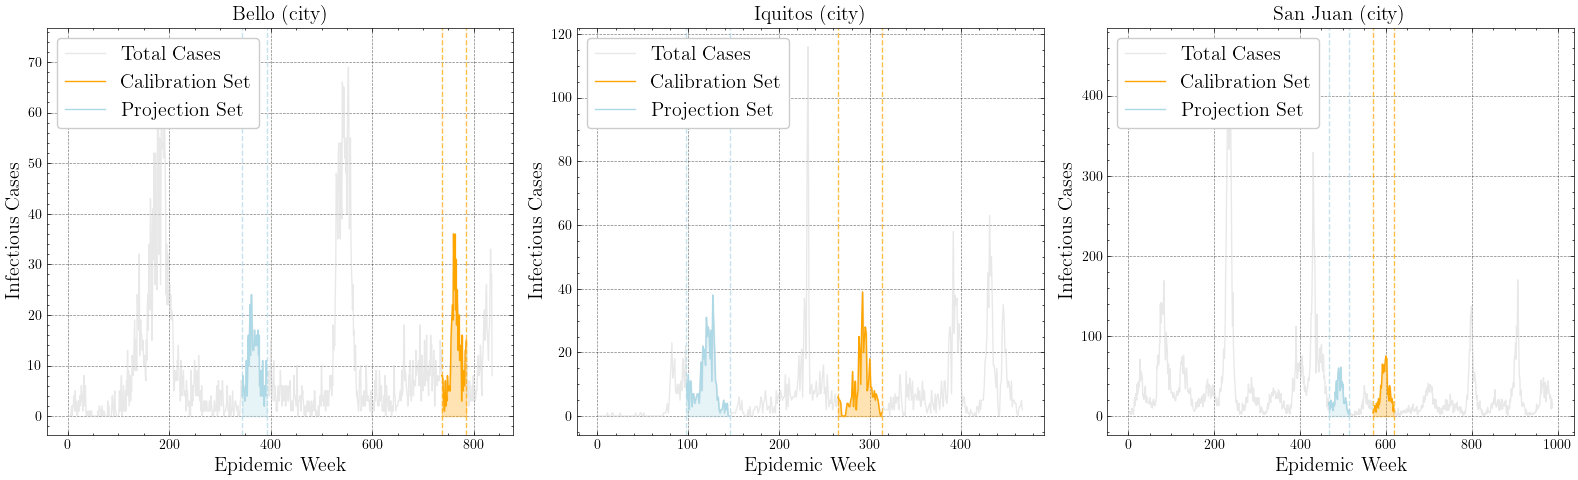

In [37]:
# First figure - top row
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# BELLO, IQUITOS, SAN JUAN
# Bello
bello_hi_true = pd.read_csv("bello/DataBello_full.csv").reset_index(drop=True)
bello_x = bello_hi_true['Epidemic_Week'].to_numpy(dtype=float)
bello_y = bello_hi_true['Cases'].to_numpy(dtype=float)
axs[0].plot(bello_x, bello_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
cali_start, cali_end = 737, 785
mask = (bello_x >= cali_start) & (bello_x <= cali_end)
axs[0].plot(bello_x[mask], bello_y[mask], label=f"Calibration Set", color="orange")
axs[0].fill_between(bello_x[mask], bello_y[mask], color="orange", alpha=0.3)
axs[0].axvline(cali_start, color="orange", linestyle="--", alpha=0.7)
axs[0].axvline(cali_end, color="orange", linestyle="--", alpha=0.7)

# Projection Set
proj_start, proj_end = 344, 392
mask = (bello_x >= proj_start) & (bello_x <= proj_end)
axs[0].plot(bello_x[mask], bello_y[mask], label=f"Projection Set", color="lightblue")
axs[0].fill_between(bello_x[mask], bello_y[mask], color="lightblue", alpha=0.3)
axs[0].axvline(proj_start, color="lightblue", linestyle="--", alpha=0.7)
axs[0].axvline(proj_end, color="lightblue", linestyle="--", alpha=0.7)

axs[0].set_title("Bello (city)", fontsize="x-large")
axs[0].set_xlabel("Epidemic Week", fontsize="x-large")
axs[0].set_ylabel("Infectious Cases", fontsize="x-large")
axs[0].legend(fontsize="x-large", loc='upper left')


# Iquitos
iquitos_hi_true = pd.read_csv("iquitos/DataIquitos_full.csv").reset_index(drop=True)
iquitos_x = iquitos_hi_true['Epidemic_Week'].to_numpy(dtype=float)
iquitos_y = iquitos_hi_true['Cases'].to_numpy(dtype=float)
axs[1].plot(iquitos_x, iquitos_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
cali_start, cali_end = 265, 313
mask = (iquitos_x >= cali_start) & (iquitos_x <= cali_end)
axs[1].plot(iquitos_x[mask], iquitos_y[mask], label=f"Calibration Set", color="orange")
axs[1].fill_between(iquitos_x[mask], iquitos_y[mask], color="orange", alpha=0.3)
axs[1].axvline(cali_start, color="orange", linestyle="--", alpha=0.7)
axs[1].axvline(cali_end, color="orange", linestyle="--", alpha=0.7)

# Projection Set
cali_start, cali_end = 98, 146
mask = (iquitos_x >= cali_start) & (iquitos_x <= cali_end)
axs[1].plot(iquitos_x[mask], iquitos_y[mask], label=f"Projection Set", color="lightblue")
axs[1].fill_between(iquitos_x[mask], iquitos_y[mask], color="lightblue", alpha=0.3)
axs[1].axvline(cali_start, color="lightblue", linestyle="--", alpha=0.7)
axs[1].axvline(cali_end, color="lightblue", linestyle="--", alpha=0.7)

axs[1].set_title("Iquitos (city)", fontsize="x-large")
axs[1].set_xlabel("Epidemic Week", fontsize="x-large")
axs[1].set_ylabel("Infectious Cases", fontsize="x-large")
axs[1].legend(fontsize="x-large", loc='upper left')


# San Juan
sanjuan_hi_true = pd.read_csv("sanjuan/DataSanJuan_full.csv").reset_index(drop=True)
sanjuan_x = sanjuan_hi_true['Epidemic_Week'].to_numpy(dtype=float)
sanjuan_y = sanjuan_hi_true['Cases'].to_numpy(dtype=float)
axs[2].plot(sanjuan_x, sanjuan_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
cali_start, cali_end = 570, 618
mask = (sanjuan_x >= cali_start) & (sanjuan_x <= cali_end)
axs[2].plot(sanjuan_x[mask], sanjuan_y[mask], label=f"Calibration Set", color="orange")
axs[2].fill_between(sanjuan_x[mask], sanjuan_y[mask], color="orange", alpha=0.3)
axs[2].axvline(cali_start, color="orange", linestyle="--", alpha=0.7)
axs[2].axvline(cali_end, color="orange", linestyle="--", alpha=0.7)

# Projection Set
cali_start, cali_end = 467, 515
mask = (sanjuan_x >= cali_start) & (sanjuan_x <= cali_end)
axs[2].plot(sanjuan_x[mask], sanjuan_y[mask], label=f"Projection Set", color="lightblue")
axs[2].fill_between(sanjuan_x[mask], sanjuan_y[mask], color="lightblue", alpha=0.3)
axs[2].axvline(cali_start, color="lightblue", linestyle="--", alpha=0.7)
axs[2].axvline(cali_end, color="lightblue", linestyle="--", alpha=0.7)

axs[2].set_title("San Juan (city)", fontsize="x-large")
axs[2].set_xlabel("Epidemic Week", fontsize="x-large")
axs[2].set_ylabel("Infectious Cases", fontsize="x-large")
axs[2].legend(fontsize="x-large", loc='upper left')

plt.tight_layout()
# plt.savefig("submit/time_window_3_cities.tiff", dpi=500, format='tiff')
plt.show()

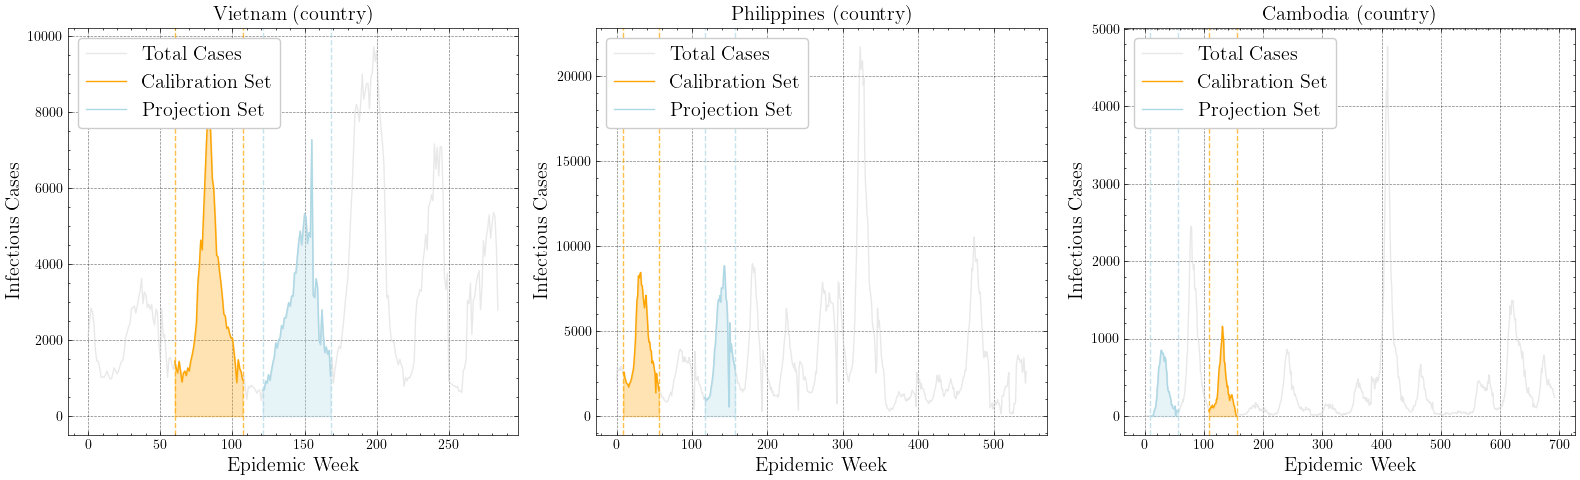

In [38]:
# Second figure - bottom row  
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# VIETNAM, PHILIPPINES, CAMBODIA
opendengue = pd.read_csv("openDengueDB_V1.3.csv", encoding="latin1")

# VIETNAM
vietnam = opendengue[opendengue["adm_0_name"] == "VIET NAM"].reset_index()
vietnam["calendar_start_date"] = pd.to_datetime(vietnam["calendar_start_date"])
vietnam["calendar_end_date"] = pd.to_datetime(vietnam["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]
# Calculate the difference in days
vietnam["period_days"] = (vietnam["calendar_end_date"] 
                          - vietnam["calendar_start_date"]).dt.days
# Filter for weekly data (difference == 6 or 7 days)
vietnam_cases = vietnam[vietnam["adm_1_name"].isnull() & 
    (vietnam["period_days"].between(6, 7))
].sort_values("calendar_start_date")
vietnam_cases = vietnam_cases[selected_columns].reset_index(drop=True)
vietnam_x = vietnam_cases.index.to_numpy(dtype=float)
vietnam_y = vietnam_cases['dengue_total'].to_numpy(dtype=float)
axs[0].plot(vietnam_x, vietnam_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
start_date, end_date = pd.to_datetime("2017-02-25"), pd.to_datetime("2018-02-01")
start_idx = vietnam_cases[vietnam_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = vietnam_cases[vietnam_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (vietnam_x >= start_idx) & (vietnam_x <= end_idx)
axs[0].plot(vietnam_x[mask], vietnam_y[mask], 
               label=f"Calibration Set", color="orange")
axs[0].fill_between(vietnam_x[mask], vietnam_y[mask], 
                       color="orange", alpha=0.3)
axs[0].axvline(start_idx, color="orange", linestyle="--", alpha=0.7)
axs[0].axvline(end_idx, color="orange", linestyle="--", alpha=0.7)

# Projection Set
start_date, end_date = pd.to_datetime("2018-04-25"), pd.to_datetime("2019-04-01")
start_idx = vietnam_cases[vietnam_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = vietnam_cases[vietnam_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (vietnam_x >= start_idx) & (vietnam_x <= end_idx)
axs[0].plot(vietnam_x[mask], vietnam_y[mask], 
               label=f"Projection Set", color="lightblue")
axs[0].fill_between(vietnam_x[mask], vietnam_y[mask], 
                       color="lightblue", alpha=0.3)
axs[0].axvline(start_idx, color="lightblue", linestyle="--", alpha=0.7)
axs[0].axvline(end_idx, color="lightblue", linestyle="--", alpha=0.7)

axs[0].set_title("Vietnam (country)", fontsize="x-large")
axs[0].set_xlabel("Epidemic Week", fontsize="x-large")
axs[0].set_ylabel("Infectious Cases", fontsize="x-large")
axs[0].legend(fontsize="x-large", loc='upper left')


# PHILIPPINES
philippines = opendengue[opendengue["adm_0_name"] == "PHILIPPINES"].reset_index()
philippines["calendar_start_date"] = pd.to_datetime(philippines["calendar_start_date"])
philippines["calendar_end_date"] = pd.to_datetime(philippines["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]
# Calculate the difference in days
philippines["period_days"] = (philippines["calendar_end_date"] 
                          - philippines["calendar_start_date"]).dt.days
# Filter for weekly data (difference == 6 or 7 days)
philippines_cases = philippines[philippines["adm_1_name"].isnull() & 
    (philippines["period_days"].between(6, 7))
].sort_values("calendar_start_date")
philippines_cases = philippines_cases[selected_columns].reset_index(drop=True)
philippines_x = philippines_cases.index.to_numpy(dtype=float)
philippines_y = philippines_cases['dengue_total'].to_numpy(dtype=float)
axs[1].plot(philippines_x, philippines_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
start_date, end_date = pd.to_datetime("2013-03-01"), pd.to_datetime("2014-02-01")
start_idx = philippines_cases[philippines_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = philippines_cases[philippines_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (philippines_x >= start_idx) & (philippines_x <= end_idx)
axs[1].plot(philippines_x[mask], philippines_y[mask], 
               label=f"Calibration Set", color="orange")
axs[1].fill_between(philippines_x[mask], philippines_y[mask], 
                       color="orange", alpha=0.3)
axs[1].axvline(start_idx, color="orange", linestyle="--", alpha=0.7)
axs[1].axvline(end_idx, color="orange", linestyle="--", alpha=0.7)

# Projection Set
start_date, end_date = pd.to_datetime("2015-04-01"), pd.to_datetime("2016-03-01")
start_idx = philippines_cases[philippines_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = philippines_cases[philippines_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (philippines_x >= start_idx) & (philippines_x <= end_idx)
axs[1].plot(philippines_x[mask], philippines_y[mask], 
               label=f"Projection Set", color="lightblue")
axs[1].fill_between(philippines_x[mask], philippines_y[mask], 
                       color="lightblue", alpha=0.3)
axs[1].axvline(start_idx, color="lightblue", linestyle="--", alpha=0.7)
axs[1].axvline(end_idx, color="lightblue", linestyle="--", alpha=0.7)

axs[1].set_title("Philippines (country)", fontsize="x-large")
axs[1].set_xlabel("Epidemic Week", fontsize="x-large")
axs[1].set_ylabel("Infectious Cases", fontsize="x-large")
axs[1].legend(fontsize="x-large", loc='upper left')


# CAMBODIA
cambodia = opendengue[opendengue["adm_0_name"] == "CAMBODIA"].reset_index()
cambodia["calendar_start_date"] = pd.to_datetime(cambodia["calendar_start_date"])
cambodia["calendar_end_date"] = pd.to_datetime(cambodia["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]
# Calculate the difference in days
cambodia["period_days"] = (cambodia["calendar_end_date"] 
                          - cambodia["calendar_start_date"]).dt.days
# Filter for weekly data (difference == 6 or 7 days)
cambodia_cases = cambodia[(cambodia["period_days"].between(6, 7))].sort_values("calendar_start_date")
cambodia_cases = cambodia_cases[selected_columns].reset_index(drop=True)
cambodia_x = cambodia_cases.index.to_numpy(dtype=float)
cambodia_y = cambodia_cases['dengue_total'].to_numpy(dtype=float)
axs[2].plot(cambodia_x, cambodia_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
start_date, end_date = pd.to_datetime("2013-01-25"), pd.to_datetime("2014-01-01")
start_idx = cambodia_cases[cambodia_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = cambodia_cases[cambodia_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (cambodia_x >= start_idx) & (cambodia_x <= end_idx)
axs[2].plot(cambodia_x[mask], cambodia_y[mask], 
               label=f"Calibration Set", color="orange")
axs[2].fill_between(cambodia_x[mask], cambodia_y[mask], 
                       color="orange", alpha=0.3)
axs[2].axvline(start_idx, color="orange", linestyle="--", alpha=0.7)
axs[2].axvline(end_idx, color="orange", linestyle="--", alpha=0.7)

# Projection Set
start_date, end_date = pd.to_datetime("2011-03-01"), pd.to_datetime("2012-02-05")
start_idx = cambodia_cases[cambodia_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = cambodia_cases[cambodia_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (cambodia_x >= start_idx) & (cambodia_x <= end_idx)
axs[2].plot(cambodia_x[mask], cambodia_y[mask], 
               label=f"Projection Set", color="lightblue")
axs[2].fill_between(cambodia_x[mask], cambodia_y[mask], 
                       color="lightblue", alpha=0.3)
axs[2].axvline(start_idx, color="lightblue", linestyle="--", alpha=0.7)
axs[2].axvline(end_idx, color="lightblue", linestyle="--", alpha=0.7)

axs[2].set_title("Cambodia (country)", fontsize="x-large")
axs[2].set_xlabel("Epidemic Week", fontsize="x-large")
axs[2].set_ylabel("Infectious Cases", fontsize="x-large")
axs[2].legend(fontsize="x-large", loc='upper left')


plt.tight_layout()
# plt.savefig("submit/time_window_3_countries.tiff", dpi=500, format='tiff')
plt.show()

# Visualise sensitivity analysis and uncertainty analysis R0 (basic reproductive number)
The value of R0 is being computed in Matlab and we include the output here for visualisation only

### Bello, Iquitos and San Juan

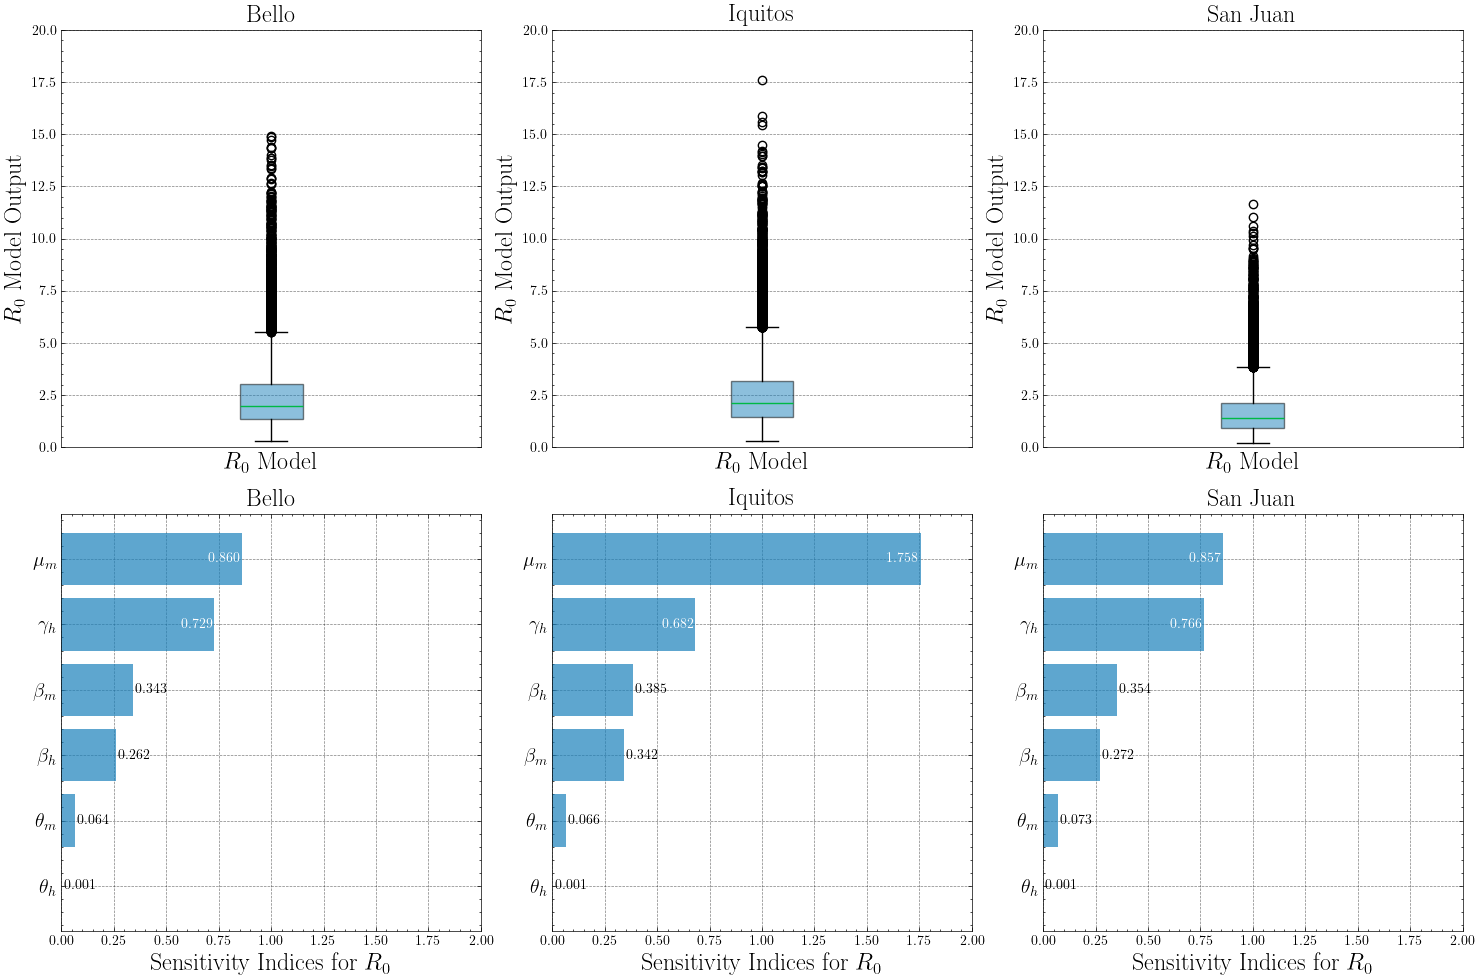

In [4]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# City data configuration
cities = {
    'Bello': {
        'mat_file': 'bello/R0_bello.mat',
        'sa_data': {r"$\beta_m$": 0.3429, r"$\beta_h$": 0.2622, r"$\theta_m$": 0.0643,
                    r"$\theta_h$": 0.000758, r"$\mu_m$": 0.8599, r"$\gamma_h$": 0.7289}
    },
    'Iquitos': {
        'mat_file': 'iquitos/R0_iquitos.mat',
        'sa_data': {r"$\beta_m$": 0.3423, r"$\beta_h$": 0.3850, r"$\theta_m$": 0.0663,
                    r"$\theta_h$": 0.0012, r"$\mu_m$": 1.7582, r"$\gamma_h$": 0.6817}
    },
    'San Juan': {
        'mat_file': 'sanjuan/R0_sanjuan.mat',
        'sa_data': {r"$\beta_m$": 0.3541, r"$\beta_h$": 0.2718, r"$\theta_m$": 0.0727,
                    r"$\theta_h$": 0.00055, r"$\mu_m$": 0.8571, r"$\gamma_h$": 0.7665}
    }
}

# Create the 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, (city_name, city_data) in enumerate(cities.items()):
    # Load R0 data
    mat = scipy.io.loadmat(city_data['mat_file'])
    R0_values = mat['ans'].squeeze()
    
    # Top row: R0 box plots
    ax_r0 = axes[0, col]
    ax_r0.boxplot(R0_values, vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='#1a80bb', alpha=0.5))
    ax_r0.set_xlabel(r"$R_0$ Model", fontsize="xx-large")
    ax_r0.set_ylabel(r"$R_0$ Model Output", fontsize="xx-large")
    if city_name == "sanjuan":
        ax_r0.set_title(f"San Juan", fontsize="xx-large")
    else:
        ax_r0.set_title(f"{city_name}", fontsize="xx-large")

    ax_r0.tick_params(axis='x', labelsize="x-large")
    ax_r0.set_xticks([])
    ax_r0.set_ylim(0, 20)
    ax_r0.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Bottom row: Sensitivity analysis
    ax_sa = axes[1, col]
    sa_r0 = city_data['sa_data']
    
    # Sort parameters by value
    sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
    params = [k for k, v in sorted_items]
    values = [v for k, v in sorted_items]
    largest_indices = np.argsort(values)[-2:]
    
    bars = ax_sa.barh(params, values, color="#1a80bb", alpha=0.7)
    
    # Add value labels on bars
    for idx, (bar, value) in enumerate(zip(bars, values)):
        if idx in largest_indices:
            ax_sa.text(
                bar.get_width() - 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='right',
                fontsize="medium",
                color='white' if bar.get_width() > 0.15 else 'black'
            )
        else:
            ax_sa.text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='left',
                fontsize="medium",
                color='black'
            )
    
    ax_sa.set_xlabel(r"Sensitivity Indices for $R_0$", fontsize="xx-large")
    if city_name == "sanjuan":
        ax_sa.set_title(f"San Juan", fontsize="xx-large")
    else:
        ax_sa.set_title(f"{city_name}", fontsize="xx-large")
    ax_sa.grid(axis='x', linestyle='--', alpha=0.5)
    ax_sa.set_xlim(0, 2.0)
    ax_sa.set_yticklabels(params, fontweight='bold', fontsize="x-large")

plt.tight_layout()
# plt.savefig("submit/r0_sa_analysis_city.tiff", dpi=400, format='tiff')
plt.show()

### Vietnam, Cambodia and the Philippines

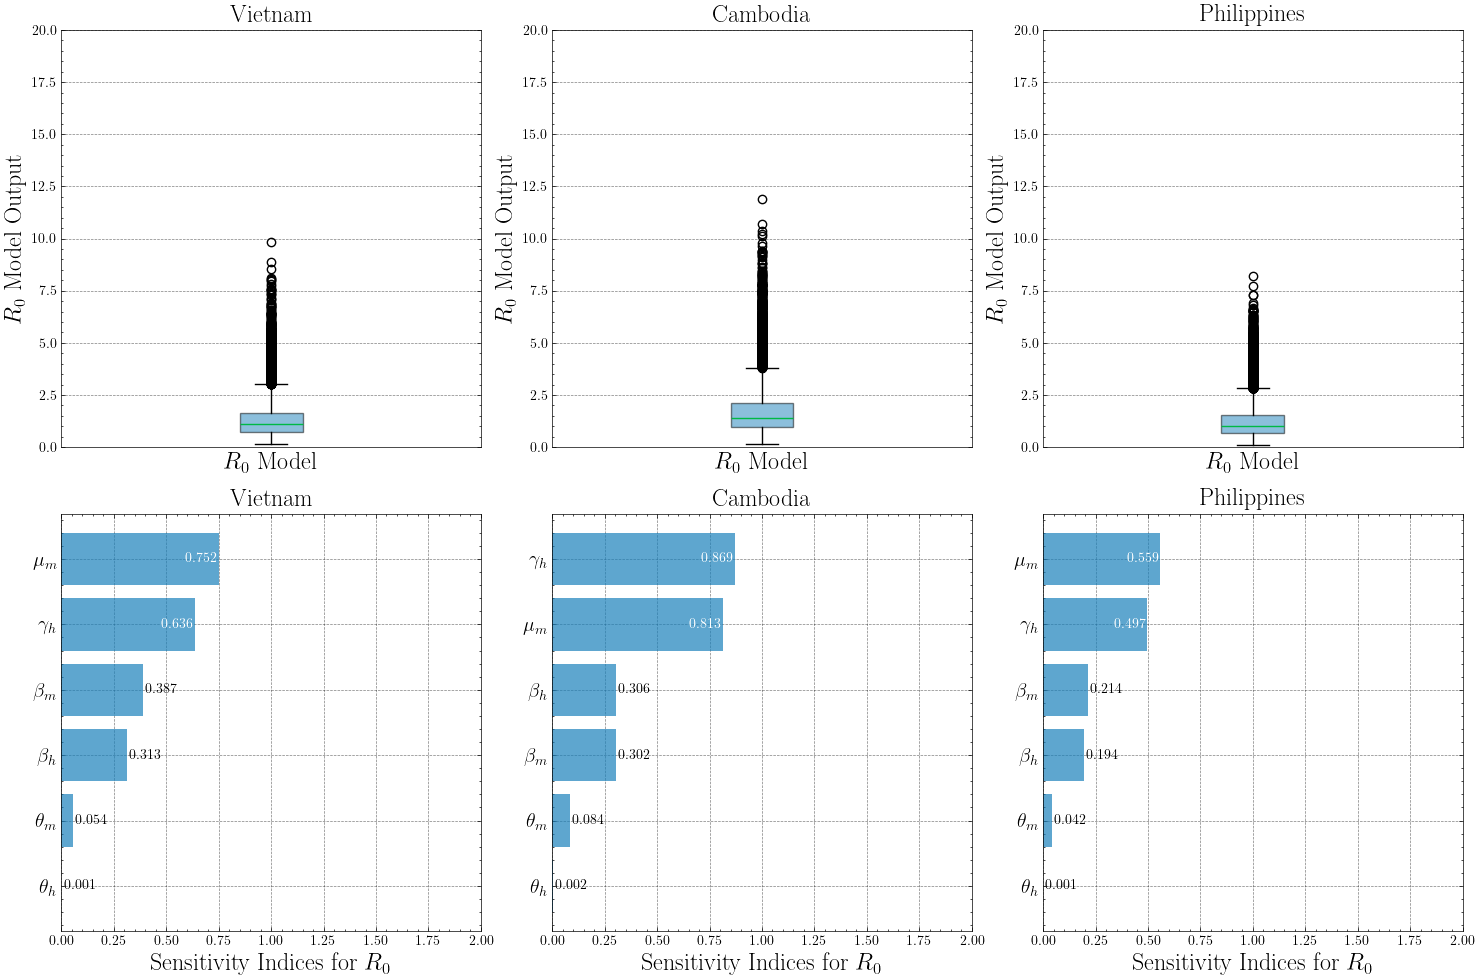

In [40]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# Country data configuration
countries = {
    'Vietnam': {
        'mat_file': 'vietnam/R0_vietnam.mat',
        'sa_data': {r"$\beta_m$": 0.3874, r"$\beta_h$": 0.31299, r"$\theta_m$": 0.0536,
                    r"$\theta_h$": 0.00087, r"$\mu_m$": 0.75206, r"$\gamma_h$": 0.6362}
    },
    'Cambodia': {
        'mat_file': 'cambodia/R0_cambodia.mat',
        'sa_data': {r"$\beta_m$": 0.3023, r"$\beta_h$": 0.306, r"$\theta_m$": 0.0843,
                    r"$\theta_h$": 0.0024, r"$\mu_m$": 0.8128, r"$\gamma_h$": 0.8693}
    },
    'Philippines': {
        'mat_file': 'philippines/R0_philippines.mat',
        'sa_data': {r"$\beta_m$": 0.2137, r"$\beta_h$": 0.1937, r"$\theta_m$": 0.0424,
                    r"$\theta_h$": 0.0005, r"$\mu_m$": 0.5589, r"$\gamma_h$": 0.4971}
    }
}

# Create the 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, (country_name, country_data) in enumerate(countries.items()):
    # Load R0 data
    mat = scipy.io.loadmat(country_data['mat_file'])
    R0_values = mat['ans'].squeeze()
    
    # Top row: R0 box plots
    ax_r0 = axes[0, col]
    ax_r0.boxplot(R0_values, vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='#1a80bb', alpha=0.5))
    ax_r0.set_xlabel(r"$R_0$ Model", fontsize="xx-large")
    ax_r0.set_ylabel(r"$R_0$ Model Output", fontsize="xx-large")
    ax_r0.set_title(f"{country_name}", fontsize="xx-large")
    ax_r0.tick_params(axis='x', labelsize="x-large")
    ax_r0.set_xticks([])
    ax_r0.set_ylim(0, 20)
    ax_r0.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Bottom row: Sensitivity analysis
    ax_sa = axes[1, col]
    sa_r0 = country_data['sa_data']
    
    # Sort parameters by value
    sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
    params = [k for k, v in sorted_items]
    values = [v for k, v in sorted_items]
    largest_indices = np.argsort(values)[-2:]
    
    bars = ax_sa.barh(params, values, color="#1a80bb", alpha=0.7)
    
    # Add value labels on bars
    for idx, (bar, value) in enumerate(zip(bars, values)):
        if idx in largest_indices:
            ax_sa.text(
                bar.get_width() - 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='right',
                fontsize="medium",
                color='white' if bar.get_width() > 0.15 else 'black'
            )
        else:
            ax_sa.text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='left',
                fontsize="medium",
                color='black'
            )
    
    ax_sa.set_xlabel(r"Sensitivity Indices for $R_0$", fontsize="xx-large")
    ax_sa.set_title(f"{country_name}", fontsize="xx-large")
    ax_sa.grid(axis='x', linestyle='--', alpha=0.5)
    ax_sa.set_xlim(0, 2.0)
    ax_sa.set_yticklabels(params, fontweight='bold', fontsize="x-large")

plt.tight_layout()
# plt.savefig("submit/r0_sa_analysis_country.tiff", dpi=400, format='tiff')
plt.show()

# Visualizse MSE along training epochs

### Visualise MSE for Bello, Iquitos and Sanjuan

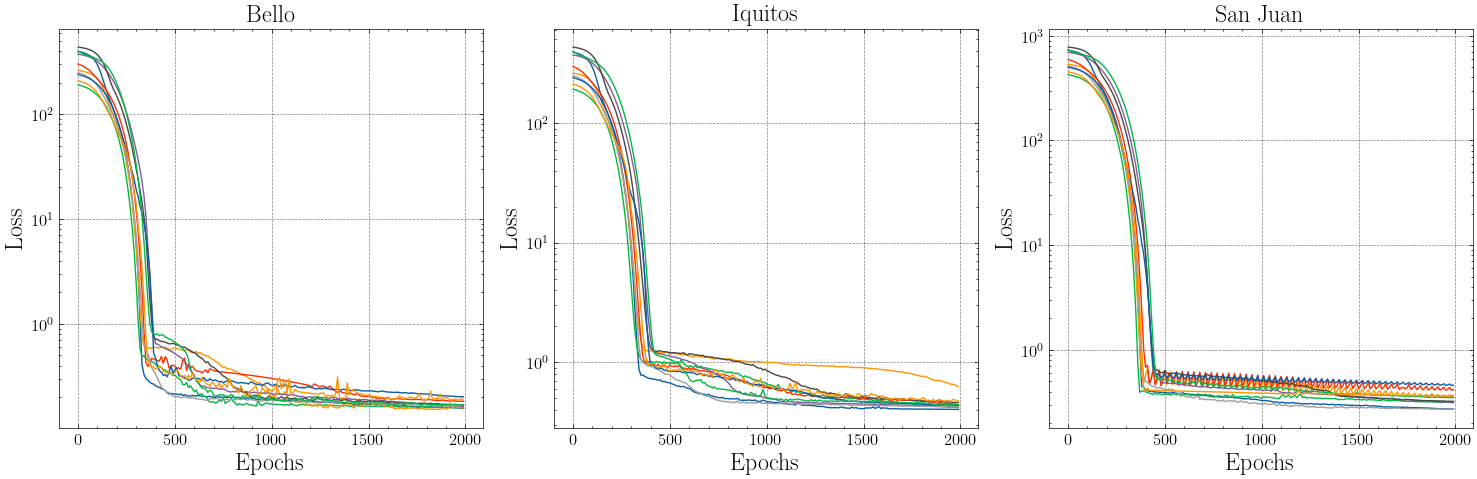

In [42]:
# Combined loss plots for 3 cities in one figure (1 row, 3 columns)
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Configuration for cities
cities = [
    {"name": "Bello", "folder": "bello", "ax": axes[0]},
    {"name": "Iquitos", "folder": "iquitos", "ax": axes[1]}, 
    {"name": "San Juan", "folder": "sanjuan", "ax": axes[2]}
]

colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for city in cities:
    ax = city["ax"]
    
    # Plot loss for each uni (1-10) for this city
    for i in range(15, 25):
        folder = f"{city['folder']}/data/uni{str(i).zfill(3)}"
        h5_path = os.path.join(folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        
        with h5py.File(h5_path, "r") as hf:
            # Assume loss is shape (n_samples,) or (n_samples, 1)
            loss = hf["Dengue"]["loss"][:]
            if loss.ndim > 1:
                loss = loss.squeeze()
            x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
            ax.plot(x, loss, label=f"uni{str(i).zfill(3)}")
    
    # Set properties for each subplot
    ax.set_xlabel("Epochs", fontsize="xx-large")
    ax.set_ylabel("Loss", fontsize="xx-large")
    ax.set_title(f"{city['name']}", fontsize="xx-large")
    ax.set_yscale("log")  # Use log scale for y-axis
    ax.tick_params(labelsize='large')
    # ax.legend(fontsize="medium", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.5)

# # Add overall title
# fig.suptitle("MSE During NPC Training with different random seeds Across Cities", fontsize="xx-large", fontweight="bold")

plt.tight_layout()
plt.savefig("npc_loss_3_cities.tiff", dpi=500, format='tiff')
plt.show()

### NPC loss for Vietnam, Cambodia and the Philippines

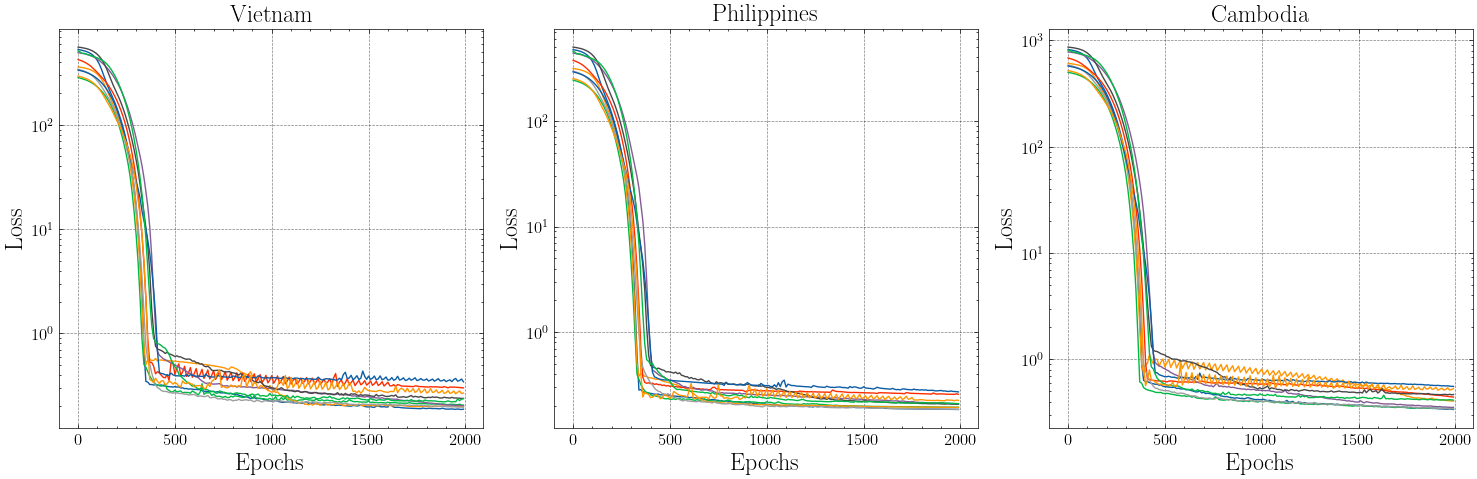

In [43]:
# Combined loss plots for 3 cities in one figure (1 row, 3 columns)
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Configuration for cities
cities = [
    {"name": "Vietnam", "folder": "vietnam", "ax": axes[0]},
    {"name": "Philippines", "folder": "philippines", "ax": axes[1]}, 
    {"name": "Cambodia", "folder": "cambodia", "ax": axes[2]}
]

for city in cities:
    ax = city["ax"]
    
    # Plot loss for each uni (1-10) for this city
    for i in range(15, 25):
        folder = f"{city['folder']}/data/uni{str(i).zfill(3)}"
        h5_path = os.path.join(folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        
        with h5py.File(h5_path, "r") as hf:
            # Assume loss is shape (n_samples,) or (n_samples, 1)
            loss = hf["Dengue"]["loss"][:]
            if loss.ndim > 1:
                loss = loss.squeeze()
            x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
            ax.plot(x, loss, label=f"uni{str(i).zfill(3)}")
    
    # Set properties for each subplot
    ax.set_xlabel("Epochs", fontsize="xx-large")
    ax.set_ylabel("Loss", fontsize="xx-large")
    ax.set_title(f"{city['name']}", fontsize="xx-large")
    ax.set_yscale("log")  # Use log scale for y-axis
    ax.tick_params(labelsize='large')
    # ax.legend(fontsize="medium", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.5)

# # Add overall title
# fig.suptitle("MSE Loss during NPC Training with different random seeds across Countries", fontsize="xx-large", fontweight="bold")

plt.tight_layout()
plt.savefig("npc_loss_3_countries.tiff", dpi=500, format='tiff')
plt.show()

# Parameter ranges from Neural Parameter Calibration for MCMC

### Bello

In [52]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 101):
    folder = f"bello/data/uni{str(i).zfill(3)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        # print(f"Processed {h5_path}")

print("Parameter ranges across all uni folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Parameter ranges across all uni folders:
Hi0: min=0.000005, max=2.114707
Me0: min=0.000007, max=1.340766
Hr0: min=0.000011, max=2.194732
Hs0: min=0.432664, max=2.760642
He0: min=0.003155, max=2.488695
Ms0: min=0.000414, max=2.620756
Mi0: min=0.000007, max=1.516265
beta_h: min=0.004198, max=1.172130
beta_m: min=0.031640, max=1.683969
gamma_h: min=0.000001, max=1.660815
lambda: min=0.000000, max=1.910173
mu_m: min=0.000001, max=0.753167
theta_h: min=0.092531, max=1.621410
theta_m: min=0.018615, max=1.819891


### Iquitos

In [53]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 101):
    folder = f"iquitos/data/uni{str(i).zfill(3)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        # print(f"Processed {h5_path}")

print("Parameter ranges across all uni folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Parameter ranges across all uni folders:
Hi0: min=0.000011, max=2.179646
Me0: min=0.000002, max=1.251645
Hr0: min=0.000014, max=2.739965
Hs0: min=0.433664, max=3.326517
He0: min=0.004669, max=2.595438
Ms0: min=0.001697, max=2.740782
Mi0: min=0.000001, max=1.475957
beta_h: min=0.005987, max=1.170617
beta_m: min=0.032629, max=1.522117
gamma_h: min=0.000000, max=1.631744
lambda: min=0.000001, max=1.662736
mu_m: min=0.000005, max=0.752741
theta_h: min=0.066308, max=1.592601
theta_m: min=0.023949, max=1.807777


### San Juan

In [54]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 101):
    folder = f"sanjuan/data/uni{str(i).zfill(3)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        # print(f"Processed {h5_path}")

print("Parameter ranges across all uni folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Parameter ranges across all uni folders:
Hi0: min=0.000015, max=2.496667
Me0: min=0.000004, max=1.807214
Hr0: min=0.000012, max=3.362601
Hs0: min=0.433271, max=3.332258
He0: min=0.003899, max=3.055965
Ms0: min=0.000393, max=2.630610
Mi0: min=0.000227, max=1.672199
beta_h: min=0.005295, max=1.211485
beta_m: min=0.032224, max=1.509890
gamma_h: min=0.000013, max=1.870964
lambda: min=0.000000, max=1.603703
mu_m: min=0.000002, max=0.752905
theta_h: min=0.127247, max=1.733796
theta_m: min=0.016852, max=1.878974


### Vietnam

In [55]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 101):
    folder = f"vietnam/data/uni{str(i).zfill(3)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        # print(f"Processed {h5_path}")

print("Parameter ranges across all uni folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Parameter ranges across all uni folders:
Hi0: min=0.000016, max=2.167864
Me0: min=0.000006, max=1.654529
Hr0: min=0.000057, max=2.291769
Hs0: min=0.426615, max=3.025496
He0: min=0.016326, max=2.691352
Ms0: min=0.001167, max=2.325766
Mi0: min=0.000003, max=1.603640
beta_h: min=0.016856, max=1.184659
beta_m: min=0.021352, max=1.768559
gamma_h: min=0.000001, max=1.790857
lambda: min=0.000001, max=1.974932
mu_m: min=0.000001, max=0.752748
theta_h: min=0.124081, max=1.700944
theta_m: min=0.010898, max=1.872209


### Cambodia

In [56]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 101):
    folder = f"cambodia/data/uni{str(i).zfill(3)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        # print(f"Processed {h5_path}")

print("Parameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000005, max=2.558673
Me0: min=0.000001, max=1.844022
Hr0: min=0.000004, max=2.746030
Hs0: min=0.428922, max=3.554773
He0: min=0.010374, max=3.169953
Ms0: min=0.000269, max=2.594243
Mi0: min=0.000019, max=1.716639
beta_h: min=0.010856, max=1.238664
beta_m: min=0.026529, max=1.869074
gamma_h: min=0.000002, max=1.927991
lambda: min=0.000001, max=2.412908
mu_m: min=0.000005, max=0.754146
theta_h: min=0.126665, max=1.782835
theta_m: min=0.013777, max=1.919252


### Philippines

In [57]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 101):
    folder = f"philippines/data/uni{str(i).zfill(3)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        # print(f"Processed {h5_path}")

print("Parameter ranges across all uni folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Parameter ranges across all uni folders:
Hi0: min=0.000008, max=2.052346
Me0: min=0.000001, max=1.592570
Hr0: min=0.000012, max=2.230670
Hs0: min=0.426474, max=2.911179
He0: min=0.017063, max=2.550279
Ms0: min=0.000313, max=2.198307
Mi0: min=0.000010, max=1.618253
beta_h: min=0.017548, max=1.182528
beta_m: min=0.017084, max=1.513547
gamma_h: min=0.000003, max=1.758503
lambda: min=0.000006, max=1.698780
mu_m: min=0.000001, max=0.752337
theta_h: min=0.123560, max=1.709962
theta_m: min=0.013670, max=1.874802


# Clean the code

In [50]:
from pathlib import Path
from typing import Iterable

def clean_uni_folders(root: Path | str,
                      targets: Iterable[str] = ("config.yml", "out.log"),
                      recursive: bool = False,
                      dry_run: bool = False) -> int:
    """
    Remove target files inside uni* folders under root.

    Args:
        root: Parent directory path.
        targets: Iterable of filenames to delete in each uni* folder.
        recursive: If True, search uni* folders at any depth (rglob). If False, only direct children (glob).
        dry_run: If True, only print what would be deleted.
    Returns:
        Count of files successfully removed.
    """
    root = Path(root)
    finder = root.rglob if recursive else root.glob
    deleted = 0
    targets_set = set(targets)

    for uni_dir in finder("uni*"):
        if not uni_dir.is_dir():
            continue
        for name in targets_set:
            p = uni_dir / name
            if p.exists():
                if dry_run:
                    print(f"[DRY RUN] Would delete: {p}")
                else:
                    p.unlink(missing_ok=True)  # safe: no error if already removed
                    deleted += 1
    return deleted

In [51]:
# Delete in direct uni* children
cleaned = clean_uni_folders("bello/data")
print(f"Deleted {cleaned} files.")

cleaned = clean_uni_folders("iquitos/data")
print(f"Deleted {cleaned} files.")

cleaned = clean_uni_folders("sanjuan/data")
print(f"Deleted {cleaned} files.")

cleaned = clean_uni_folders("vietnam/data")
print(f"Deleted {cleaned} files.")

cleaned = clean_uni_folders("philippines/data")
print(f"Deleted {cleaned} files.")

cleaned = clean_uni_folders("cambodia/data")
print(f"Deleted {cleaned} files.")

Deleted 0 files.
Deleted 0 files.
Deleted 0 files.
Deleted 0 files.
Deleted 0 files.
Deleted 0 files.
